# Diamond Creek ETF Arbitrage — Backtest v9


**v8:** Keeps the same v7 engine/data/costs, and adds a new weighting method that combines **backtest PnL/Gross** with **screener net decay signal** (`data/etf_screened_today.csv`), then applies a **shares-available capacity cap** so short ETF targets do not exceed a configurable fraction of available lendable shares.

**Dynamic target gross multiple:** **`V7_TARGET_LEV_START` → `V7_TARGET_LEV_END`** (default **4.5× → 5.0×** NAV) as a function of how many **post-start** candidate pairs have **non-trivial gross** on the book.

**Later cells:** After the equal-weight run, save NAVs + build **v8 combined weights**, then re-backtest with **`v8_pnl_decay_shares_weights.csv`**. Final section adds a historical **shares-available** analysis from `data/runs/*/etf_screened_today.csv`.


## Setup


In [75]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests, time, ftplib, io, os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

TRADING_DAYS = 252
norm_sym = lambda x: str(x).strip().upper().replace(".", "-")
print("Imports OK")


Imports OK


## Configuration


In [ ]:
CFG = {
    "capital_usd":          10_000_000,
    "start_date":           "2023-01-01",
    "slippage_bps":         20,
    "ibkr_comm_per_share":  0.005,
    "ibkr_comm_min":        1.00,
    "ibkr_comm_max_pct":    0.005,
    "fallback_borrow_rate": 0.02,
    # Clear Street financing assumptions from proposal:
    # debit = OBFR + 45 bps, credit = OBFR - 40 bps.
    "margin_debit_spreads": [
        (float("inf"), 0.0045),
    ],
    "credit_threshold":     10_000,
    "credit_spread":        -0.0040,
    "skip_ftp":             False,
    "dead_band_pct":        0.02,
    "gross_dead_band_pct":  0.05,       # full position resize if portfolio gross drifts > 5% from target
    "weight_power":         2,          # exponent applied to PnL/Gross ratios before normalising weights
    "mix_decay_weight":     0.45,       # blend: 0=dPnL/Gross only, 1=decay-score only
    "decay_weight_power":   1.25,       # exponent on positive decay signal
    "position_concentration_power": 1.35, # >1 tilts more weight to biggest names
    "short_avail_use_pct":  0.25,       # softer cap: can target up to 25% of reported shares_available
    "max_pair_weight_cap":  0.10,       # hard max portfolio weight per pair after capacity logic
    "max_underlying_weight_cap": 0.20,  # hard max aggregate weight per underlying
    "missing_shares_cap":   0.03,       # softer fallback cap when shares_available is missing
    "cap_ramp_rebals":      3,          # raise cap-constrained names over next 3 rebalances
}

LEVERAGE_RUNS = [4.5]

V7_TARGET_LEV_START = 4.5   # incumbent day-0 sizing; floor for target multiple
V7_TARGET_LEV_END = 5.0     # target multiple once all post-start pairs are on book

print(f"Capital: ${CFG['capital_usd']:,}  |  Start: {CFG['start_date']}")
print(f"Leverage: {LEVERAGE_RUNS}  |  v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x")
print("Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)")


Capital: $10,000,000  |  Start: 2023-01-01
Leverage: [4.5]  |  v8 target gross multiple: 4.5x → 5.0x
Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)


## PM margin — Diamond Creek sample book

Long/short equity book (~70 US names, mainly large caps and ETFs). **Source:** `data/backtest/PM Report Diamond Creek 20260326 CV.xlsx` → *Top Level Summary*.

PM notes (narrative): regulatory-style requirement lands near **$6.5MM**; **discretionary** add-on tied to crypto proxies (BITU, BITX, ETHA, ETHT, ETHU, IBIT, SOEZ); **concentration** add-on on largest names (e.g. NVDA, TSLA); small **liquidity** add-on (SOEZ). **PM/GMV** in the file is *Effective margin requirement ÷ GMV* (~17%).

The next cell loads the spreadsheet and estimates **margin excess** if gross exposure were raised to **4.5× equity** (same equity, higher GMV), by applying the file’s **MR/GMV** ratio to the new gross (equivalent to scaling today’s effective margin **linearly with GMV** when the report is internally consistent).


In [77]:
PM_XLSX = Path("data/backtest/PM Report Diamond Creek 20260326 CV.xlsx")
TARGET_GROSS_LEV = 4.5  # gross market value / equity


def _pm_top_level_snapshot(path: Path) -> dict[str, float]:
    """Parse key fields from 'Top Level Summary' (label in col 0, current in col 1)."""
    tl = pd.read_excel(path, sheet_name="Top Level Summary", header=None)
    labels = tl[0].astype(str).str.strip()

    def row_val(label: str) -> float:
        m = labels == label
        if not m.any():
            raise KeyError(f"missing row {label!r} in Top Level Summary")
        v = tl.loc[m.idxmax(), 1]
        return float(v)

    equity = row_val("Equity")
    eff_mr = row_val("Effective Margin Requirement")
    margin_xs = row_val("Margin Excess/Deficit")
    lmv = row_val("Long Market Value")
    smv = row_val("Short Market Value")
    gmv = row_val("Gross Market Value")
    try:
        pm_over_gmv = row_val("Effective Requirement / GMV")
    except KeyError:
        pm_over_gmv = eff_mr / gmv if gmv else float("nan")

    gross_lev = gmv / equity if equity else float("nan")
    return {
        "equity": equity,
        "effective_margin_req": eff_mr,
        "margin_excess": margin_xs,
        "lmv": lmv,
        "smv": smv,
        "gmv": gmv,
        "pm_over_gmv": pm_over_gmv,
        "gross_leverage_x": gross_lev,
    }


if not PM_XLSX.exists():
    print(f"[PM] Skipping margin snapshot: file not found at {PM_XLSX}")
else:
    sn = _pm_top_level_snapshot(PM_XLSX)
    eq = sn["equity"]
    gmv0 = sn["gmv"]
    mr0 = sn["effective_margin_req"]
    r = sn["pm_over_gmv"]

    gmv_tgt = TARGET_GROSS_LEV * eq
    # Constant MR/GMV ratio (same mix in % of gross). Equivalent to scaling today's $ requirement
    # linearly with GMV when Effective MR = (MR/GMV) × GMV in the report.
    mr_stressed = r * gmv_tgt
    xs_stressed = eq - mr_stressed
    mr_linear_check = mr0 * (gmv_tgt / gmv0) if gmv0 else float("nan")

    print("--- Diamond Creek PM snapshot (from xlsx) ---")
    print(f"Equity:                 ${eq:>17,.0f}")
    print(f"LMV / SMV:              ${sn['lmv']:>17,.0f}  /  ${sn['smv']:>17,.0f}")
    print(f"GMV:                    ${gmv0:>17,.0f}  |  implied gross lev: {sn['gross_leverage_x']:.2f}x")
    print(f"Effective margin req:   ${mr0:>17,.0f}  |  MR/GMV: {r * 100:.2f}%")
    print(f"Margin excess (report): ${sn['margin_excess']:>17,.0f}")
    print()
    print(f"--- Stress: {TARGET_GROSS_LEV:.1f}x gross on same equity ---")
    print(f"Target GMV ({TARGET_GROSS_LEV:.1f} × equity): ${gmv_tgt:>17,.0f}")
    print()
    print("Implied requirement (constant MR/GMV × target GMV):")
    print(f"  Margin need:            ${mr_stressed:>17,.0f}")
    print(f"  Margin excess:          ${xs_stressed:>17,.0f}  ({100 * xs_stressed / eq:.2f}% of equity)")
    print(f"  vs reported excess:     ${sn['margin_excess']:>17,.0f}  -> buffer vs today ${sn['margin_excess'] - xs_stressed:,.0f}")
    if gmv0 and abs(mr_linear_check - mr_stressed) < 1.0:
        print()
        print("(Linear GMV scaling from today's $ margin matches this when MR/GMV is consistent with the file.)")


[PM] Skipping margin snapshot: file not found at data\backtest\PM Report Diamond Creek 20260326 CV.xlsx


## Universe — v7 (same hardcoded list as v6 from `DC_Universe_Map_Filtered.xlsx`)



In [78]:
# Hardcoded from DC_Universe_Map_Filtered.xlsx (sheet "Universe Map") — all ETF slots, |β| rounded to 3dp.
CANDIDATES = [
    ("SMU", "SMR", 1.986),   ("SMUP", "SMR", 2.058),  ("QBTX", "QBTS", 1.993),
    ("BMNU", "BMNR", 1.944), ("BMNG", "BMNR", 1.993), ("ASTX", "ASTS", 1.990),
    ("CRWG", "CRWV", 1.997), ("CWVX", "CRWV", 1.990), ("WULX", "WULF", 1.997),
    ("NEBX", "NBIS", 1.999), ("NBIL", "NBIS", 1.998), ("NBIG", "NBIS", 2.009),
    ("SMCL", "SMCI", 1.990), ("CRCA", "CRCL", 1.978), ("CRCG", "CRCL", 1.990),
    ("LABX", "ALAB", 1.994), ("BEX", "BE", 1.977),    ("CLSX", "CLSK", 1.999),
    ("GLXU", "GLXY", 2.012), ("XXRP", "XRPZ", 2.020), ("XRPT", "XRPZ", 2.018),
    ("ETHU", "ETHA", 2.001), ("ETHT", "ETHA", 1.991), ("ETU", "ETHA", 1.990),
    ("CRDU", "CRDO", 1.988), ("FIGG", "FIG", 1.996),  ("SOLT", "SOEZ", 2.014),
    ("CONL", "COIN", 1.987), ("APPX", "APP", 1.984),  ("UUUG", "UUUU", 1.995),
    ("SOXL", "SOXX", 2.960), ("ROBN", "HOOD", 2.012), ("HOOG", "HOOD", 2.007),
    ("LITX", "LITE", 1.980), ("INTW", "INTC", 1.988), ("UPSX", "UPST", 1.989),
    ("CSEX", "CLS", 1.998),  ("MUU", "MU", 1.994),    ("MULL", "MU", 1.997),
    ("ARCX", "ACHR", 1.989), ("SATG", "SATS", 2.010), ("VRTL", "VRT", 1.982),
    ("GDXU", "GDX", 3.043),  ("NUGT", "GDX", 1.981),  ("TEMT", "TEM", 1.985),
    ("RDTL", "RDDT", 1.982), ("RBLU", "RBLX", 2.019), ("AMDL", "AMD", 1.997),
    ("AMUU", "AMD", 2.008),  ("AMDG", "AMD", 2.003),  ("TSLL", "TSLA", 1.993),
    ("TSLT", "TSLA", 1.993), ("TSLR", "TSLA", 1.999), ("TSLG", "TSLA", 1.991),
    ("BITX", "IBIT", 2.005), ("BITU", "IBIT", 1.992), ("BTCL", "IBIT", 2.007),
    ("YINN", "FXI", 2.974),  ("MVLL", "MRVL", 1.992), ("URAA", "URA", 1.933),
    ("SNOU", "SNOW", 2.024), ("BULG", "BULL", 1.985), ("PLTU", "PLTR", 1.992),
    ("PTIR", "PLTR", 1.997), ("PLTG", "PLTR", 1.996), ("BABX", "BABA", 2.006),
    ("NVDL", "NVDA", 1.988), ("NVDU", "NVDA", 1.986), ("NVDX", "NVDA", 1.997),
    ("NVDG", "NVDA", 1.969), ("LRCU", "LRCX", 2.045), ("ARMG", "ARM", 1.997),
    ("TSMU", "TSM", 1.990),  ("TSMG", "TSM", 1.979),  ("GEVX", "GEV", 1.993),
    ("KTUP", "KTOS", 2.026), ("AVL", "AVGO", 1.987),  ("AVGG", "AVGO", 1.999),
    ("AVGU", "AVGO", 1.992), ("UBRL", "UBER", 1.995), ("CRMG", "CRM", 1.984),
    ("UNHG", "UNH", 1.996),  ("MEXX", "EWW", 2.958),  ("JNUG", "GDXJ", 1.974),
    ("NFLU", "NFLX", 1.990), ("CWEB", "KWEB", 1.987), ("CEGX", "CEG", 1.979),
    ("GGLL", "GOOGL", 1.992),("GOOX", "GOOGL", 1.984),("KORU", "EWY", 2.931),
    ("TERG", "TER", 1.996),  ("DLLL", "DELL", 1.986), ("METU", "META", 1.999),
    ("FBL", "META", 1.997),  ("AMZU", "AMZN", 1.987), ("AMZZ", "AMZN", 1.992),
    ("PALU", "PANW", 2.006), ("ASMG", "ASML", 1.984), ("WDCX", "WDC", 2.055),
    ("CRWL", "CRWD", 1.997), ("ELIL", "LLY", 1.991),  ("PYPG", "PYPL", 1.995),
    ("BOEU", "BA", 1.987),   ("MSFU", "MSFT", 1.991), ("MSFL", "MSFT", 1.992),
    ("MSFX", "MSFT", 2.007), ("CHAU", "ASHR", 1.967), ("NOWL", "NOW", 1.996),
    ("ERX", "XLE", 1.988),   ("GUSH", "XOP", 2.011),  ("SHPU", "SHOP", 2.012),
    ("XOMX", "XOM", 1.969),  ("ORCU", "ORCL", 2.006), ("ADBG", "ADBE", 1.992),
    ("AAPU", "AAPL", 1.984), ("AAPB", "AAPL", 1.991), ("AAPX", "AAPL", 1.995),
    ("TARK", "ARKK", 1.978), ("LABU", "XBI", 2.988),  ("CSCL", "CSCO", 2.027),
    ("LMTL", "LMT", 1.984),  ("COTG", "COST", 1.987),
]

BASE_CANDIDATE_KEYS = {(e, u) for e, u, _ in CANDIDATES}

# Add all remaining screened pairs not already in the base map.
screen_paths = [Path("../data/etf_screened_today.csv"), Path("data/etf_screened_today.csv")]
_screen_path = next((p for p in screen_paths if p.exists()), None)
_added = 0
if _screen_path is not None:
    _sc = pd.read_csv(_screen_path)
    _sc.columns = [str(c).strip() for c in _sc.columns]
    req = {"ETF", "Underlying", "Beta"}
    if req.issubset(_sc.columns):
        _sc["ETF"] = _sc["ETF"].astype(str).str.upper().str.strip()
        _sc["Underlying"] = _sc["Underlying"].astype(str).str.upper().str.strip()
        _sc["Beta"] = pd.to_numeric(_sc["Beta"], errors="coerce")

        for r in _sc.itertuples(index=False):
            e = r.ETF
            u = r.Underlying
            b = float(r.Beta) if pd.notna(r.Beta) else np.nan
            if not e or not u or not np.isfinite(b):
                continue
            key = (e, u)
            if key in BASE_CANDIDATE_KEYS:
                continue
            CANDIDATES.append((e, u, round(abs(b), 3)))
            BASE_CANDIDATE_KEYS.add(key)
            _added += 1

EXTRA_ETFS = {e for e, u, _ in CANDIDATES if (e, u) not in {(x, y) for x, y, _ in [
    ("SMU", "SMR", 1),   ("SMUP", "SMR", 1),  ("QBTX", "QBTS", 1),
    ("BMNU", "BMNR", 1), ("BMNG", "BMNR", 1), ("ASTX", "ASTS", 1),
    ("CRWG", "CRWV", 1), ("CWVX", "CRWV", 1), ("WULX", "WULF", 1),
    ("NEBX", "NBIS", 1), ("NBIL", "NBIS", 1), ("NBIG", "NBIS", 1),
    ("SMCL", "SMCI", 1), ("CRCA", "CRCL", 1), ("CRCG", "CRCL", 1),
    ("LABX", "ALAB", 1), ("BEX", "BE", 1),    ("CLSX", "CLSK", 1),
    ("GLXU", "GLXY", 1), ("XXRP", "XRPZ", 1), ("XRPT", "XRPZ", 1),
    ("ETHU", "ETHA", 1), ("ETHT", "ETHA", 1), ("ETU", "ETHA", 1),
    ("CRDU", "CRDO", 1), ("FIGG", "FIG", 1),  ("SOLT", "SOEZ", 1),
    ("CONL", "COIN", 1), ("APPX", "APP", 1),  ("UUUG", "UUUU", 1),
    ("SOXL", "SOXX", 1), ("ROBN", "HOOD", 1), ("HOOG", "HOOD", 1),
    ("LITX", "LITE", 1), ("INTW", "INTC", 1), ("UPSX", "UPST", 1),
    ("CSEX", "CLS", 1),  ("MUU", "MU", 1),    ("MULL", "MU", 1),
    ("ARCX", "ACHR", 1), ("SATG", "SATS", 1), ("VRTL", "VRT", 1),
    ("GDXU", "GDX", 1),  ("NUGT", "GDX", 1),  ("TEMT", "TEM", 1),
    ("RDTL", "RDDT", 1), ("RBLU", "RBLX", 1), ("AMDL", "AMD", 1),
    ("AMUU", "AMD", 1),  ("AMDG", "AMD", 1),  ("TSLL", "TSLA", 1),
    ("TSLT", "TSLA", 1), ("TSLR", "TSLA", 1), ("TSLG", "TSLA", 1),
    ("BITX", "IBIT", 1), ("BITU", "IBIT", 1), ("BTCL", "IBIT", 1),
    ("YINN", "FXI", 1),  ("MVLL", "MRVL", 1), ("URAA", "URA", 1),
    ("SNOU", "SNOW", 1), ("BULG", "BULL", 1), ("PLTU", "PLTR", 1),
    ("PTIR", "PLTR", 1), ("PLTG", "PLTR", 1), ("BABX", "BABA", 1),
    ("NVDL", "NVDA", 1), ("NVDU", "NVDA", 1), ("NVDX", "NVDA", 1),
    ("NVDG", "NVDA", 1), ("LRCU", "LRCX", 1), ("ARMG", "ARM", 1),
    ("TSMU", "TSM", 1),  ("TSMG", "TSM", 1),  ("GEVX", "GEV", 1),
    ("KTUP", "KTOS", 1), ("AVL", "AVGO", 1),  ("AVGG", "AVGO", 1),
    ("AVGU", "AVGO", 1), ("UBRL", "UBER", 1), ("CRMG", "CRM", 1),
    ("UNHG", "UNH", 1),  ("MEXX", "EWW", 1),  ("JNUG", "GDXJ", 1),
    ("NFLU", "NFLX", 1), ("CWEB", "KWEB", 1), ("CEGX", "CEG", 1),
    ("GGLL", "GOOGL", 1),("GOOX", "GOOGL", 1),("KORU", "EWY", 1),
    ("TERG", "TER", 1),  ("DLLL", "DELL", 1), ("METU", "META", 1),
    ("FBL", "META", 1),  ("AMZU", "AMZN", 1), ("AMZZ", "AMZN", 1),
    ("PALU", "PANW", 1), ("ASMG", "ASML", 1), ("WDCX", "WDC", 1),
    ("CRWL", "CRWD", 1), ("ELIL", "LLY", 1),  ("PYPG", "PYPL", 1),
    ("BOEU", "BA", 1),   ("MSFU", "MSFT", 1), ("MSFL", "MSFT", 1),
    ("MSFX", "MSFT", 1), ("CHAU", "ASHR", 1), ("NOWL", "NOW", 1),
    ("ERX", "XLE", 1),   ("GUSH", "XOP", 1),  ("SHPU", "SHOP", 1),
    ("XOMX", "XOM", 1),  ("ORCU", "ORCL", 1), ("ADBG", "ADBE", 1),
    ("AAPU", "AAPL", 1), ("AAPB", "AAPL", 1), ("AAPX", "AAPL", 1),
    ("TARK", "ARKK", 1), ("LABU", "XBI", 1),  ("CSCL", "CSCO", 1),
    ("LMTL", "LMT", 1),  ("COTG", "COST", 1),
]}}

# Rebuild additions with explicit Beta filter: include only screened ETFs with Beta > 1.5.
_base_keys = {(e, u) for e, u, _ in CANDIDATES if e not in EXTRA_ETFS}
base_candidates = [t for t in CANDIDATES if (t[0], t[1]) in _base_keys]

extra_candidates = []
EXTRA_ETFS = set()
if _screen_path is not None and req.issubset(_sc.columns):
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        if b <= 1.5:
            continue
        key = (e, u)
        if key in _base_keys:
            continue
        extra_candidates.append((e, u, round(b, 3)))
        EXTRA_ETFS.add(e)

# Deduplicate while preserving order.
_seen = set()
CANDIDATES = []
for e, u, b in base_candidates + extra_candidates:
    k = (e, u)
    if k in _seen:
        continue
    _seen.add(k)
    CANDIDATES.append((e, u, b))

# Global beta filter for the entire v9 backtest universe.
MIN_BETA_ABS = 1.5
pair_beta_from_screen = {}
etf_beta_from_screen = {}
if _screen_path is not None and req.issubset(_sc.columns):
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        pair_beta_from_screen[(e, u)] = abs(b)
        etf_beta_from_screen[e] = abs(b)

_before = len(CANDIDATES)
_filtered = []
for e, u, b in CANDIDATES:
    b_abs = pair_beta_from_screen.get((e, u), etf_beta_from_screen.get(e, abs(float(b))))
    if not np.isfinite(b_abs) or b_abs <= MIN_BETA_ABS:
        continue
    _filtered.append((e, u, round(float(b_abs), 3)))
CANDIDATES = _filtered

print(
    f"Total candidate pairs: {len(CANDIDATES)} | Added from screener (positive Beta>{MIN_BETA_ABS}): {len(extra_candidates)} "
    f"| Dropped by global beta filter: {_before - len(CANDIDATES)}"
)
print(f"Additional ETF names (capacity-sized only): {len(EXTRA_ETFS)}")


Total candidate pairs: 255 | Added from screener (positive Beta>1.5): 133 | Dropped by global beta filter: 0
Additional ETF names (capacity-sized only): 133


In [79]:
# ---- Restrict universe to Clear Street sample portfolio pairs ----
sample_paths = [
    Path(r"C:/Users/werdn/Downloads/Copy of clear_street_sample_portfolio (1) (002)1.xlsx"),
    Path("data/backtest/clear_street_sample_portfolio.csv"),
    Path("../data/backtest/clear_street_sample_portfolio.csv"),
]
SAMPLE_BOOK_PATH = next((p for p in sample_paths if p.exists()), None)

if SAMPLE_BOOK_PATH is None:
    print("[SAMPLE] Sample portfolio file not found; keeping existing CANDIDATES universe.")
    sample_df = pd.DataFrame(columns=["Pair"])
elif SAMPLE_BOOK_PATH.suffix.lower() == ".csv":
    sample_df = pd.read_csv(SAMPLE_BOOK_PATH)
else:
    sample_df = pd.read_excel(SAMPLE_BOOK_PATH)

sample_df.columns = [str(c).strip() for c in sample_df.columns]
if "Pair" not in sample_df.columns:
    print("[SAMPLE] Missing Pair column; keeping existing CANDIDATES universe.")
    sample_df = pd.DataFrame(columns=["Pair"])

sample_df["Pair"] = sample_df["Pair"].astype(str).str.upper().str.strip()
sample_df = sample_df[sample_df["Pair"].str.contains("/")].copy()

# Existing beta fallback map from the hardcoded universe loaded above.
_base_beta = {(e, u): abs(float(b)) for e, u, b in CANDIDATES}

# Optional beta fallback from current screener.
screen_beta = {}
for _p in [Path("data/etf_screened_today.csv"), Path("../data/etf_screened_today.csv")]:
    if _p.exists():
        _s = pd.read_csv(_p)
        _s.columns = [str(c).strip() for c in _s.columns]
        if {"ETF", "Underlying", "Beta"}.issubset(_s.columns):
            _s["ETF"] = _s["ETF"].astype(str).str.upper().str.strip()
            _s["Underlying"] = _s["Underlying"].astype(str).str.upper().str.strip()
            _s["Beta"] = pd.to_numeric(_s["Beta"], errors="coerce")
            for _r in _s.itertuples(index=False):
                if pd.notna(_r.Beta):
                    screen_beta[(_r.ETF, _r.Underlying)] = abs(float(_r.Beta))
        break

sample_pairs = []
for pair in sample_df["Pair"].dropna().astype(str).tolist():
    und, etf = [x.strip().upper() for x in pair.split("/", 1)]
    if not und or not etf:
        continue
    sample_pairs.append((etf, und))

sample_pairs = list(dict.fromkeys(sample_pairs))

# Build sample-only candidate list with robust beta fallback.
sample_candidates = []
missing_beta = []
for etf, und in sample_pairs:
    b = _base_beta.get((etf, und), screen_beta.get((etf, und), np.nan))
    if not np.isfinite(b):
        b = 2.0  # conservative fallback for leveraged ETF hedging
        missing_beta.append((etf, und))
    sample_candidates.append((etf, und, round(abs(float(b)), 3)))

if sample_candidates:
    CANDIDATES = sample_candidates
else:
    print("[SAMPLE] No valid sample pairs found; keeping existing CANDIDATES universe.")

# Borrow-rate column in sample sheet is currently Unnamed: 6.
# Convention requested by user: positive means we GET PAID to short.
# Backtest BORROW_MAP convention: positive = we PAY borrow. So we invert sign.
borrow_col = "Unnamed: 6" if "Unnamed: 6" in sample_df.columns else None
if borrow_col is None:
    SAMPLE_BOOK_BORROW_MAP = {}
else:
    tmp = sample_df[["Pair", borrow_col]].copy()
    tmp[borrow_col] = pd.to_numeric(tmp[borrow_col], errors="coerce")
    tmp = tmp[tmp[borrow_col].notna()].copy()
    bmap = {}
    for _, r in tmp.iterrows():
        und, etf = [x.strip().upper() for x in str(r["Pair"]).split("/", 1)]
        raw_pct_points = float(r[borrow_col])
        bmap[etf] = -(raw_pct_points / 100.0)
    SAMPLE_BOOK_BORROW_MAP = bmap

print(f"Sample-book universe active: {len(CANDIDATES)} pairs")
print(f"Sample-book borrow rows: {len(SAMPLE_BOOK_BORROW_MAP)} ETFs (sign-inverted: +sheet => short credit)")
if missing_beta:
    print(f"Pairs with fallback beta=2.0: {len(missing_beta)}")


Sample-book universe active: 40 pairs
Sample-book borrow rows: 40 ETFs (sign-inverted: +sheet => short credit)


## Data — Borrow Rates, Prices, Pair Selection


In [80]:
# ---- Borrow rates (historical average first, FTP/cache fallback) ----
all_etf_syms = [e for e, _, _ in CANDIDATES]
BORROW_CACHE = Path("data/borrow_cache.csv")

# Resolve runs path robustly across notebook cwd variants.
runs_candidates = [
    Path("data/runs"),
    Path("../data/runs"),
    Path.cwd() / "data/runs",
    Path.cwd() / "../data/runs",
    Path.cwd().parent / "data/runs",
]
RUNS_ROOT = next((p.resolve() for p in runs_candidates if p.exists()), None)
if RUNS_ROOT is None:
    RUNS_ROOT = Path("data/runs")

# Build consolidated historical panel (borrow + shares) from run snapshots.
def _trimmed_mean_drop2(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
    if len(x) <= 4:
        return float(x.mean()) if len(x) else np.nan
    return float(x.iloc[2:-2].mean())


def _norm_col(c: str) -> str:
    return "".join(ch for ch in str(c).lower().strip() if ch.isalnum())


def _pick_col(cols: list[str], exact_norm: list[str], fuzzy_contains: list[str] | None = None) -> str | None:
    norm_to_orig = {_norm_col(c): c for c in cols}
    for k in exact_norm:
        if k in norm_to_orig:
            return norm_to_orig[k]
    if fuzzy_contains:
        for c in cols:
            nc = _norm_col(c)
            if all(tok in nc for tok in fuzzy_contains):
                return c
    return None


# Prefer etf_screened_today for a date, but still use proposed_trades to fill missing fields.
def _historical_snapshot_files(root: Path) -> list[tuple[pd.Timestamp, Path, int]]:
    out = []
    for d in sorted(root.glob("*")):
        if not d.is_dir():
            continue
        ds = pd.to_datetime(d.name, errors="coerce")
        if pd.isna(ds):
            continue
        f_screen = d / "etf_screened_today.csv"
        f_trades = d / "proposed_trades.csv"
        if f_screen.exists():
            out.append((ds, f_screen, 0))
        if f_trades.exists():
            out.append((ds, f_trades, 1))

    # Include current latest screener/proposed files if present.
    extra = [
        (Path("data/etf_screened_today.csv"), 2),
        (Path("../data/etf_screened_today.csv"), 2),
        (Path("data/proposed_trades.csv"), 3),
        (Path("../data/proposed_trades.csv"), 3),
    ]
    for p, rank in extra:
        if p.exists():
            dt = pd.to_datetime(p.stat().st_mtime, unit="s", errors="coerce")
            out.append((dt, p, rank))
    return out


def _extract_snapshot_rows(ds: pd.Timestamp, fp: Path, src_rank: int) -> pd.DataFrame:
    try:
        d = pd.read_csv(fp)
    except Exception:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])
    if d.empty:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    cols = list(d.columns)
    etf_col = _pick_col(cols, ["etf", "ticker", "symbol", "sym"], None)
    if etf_col is None:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    borrow_col = _pick_col(
        cols,
        [
            "borrownetannual",
            "borrowcurrent",
            "borrowfeeannual",
            "borrowrate",
            "feeborrow",
            "borrowfee",
            "shortborrowrate",
            "shortfee",
        ],
        ["borrow"],
    )

    shares_col = _pick_col(
        cols,
        [
            "sharesavailable",
            "sharesavail",
            "availableshares",
            "sharesavailableforshort",
            "shortsharesavailable",
        ],
        ["share", "avail"],
    )

    out = pd.DataFrame()
    out["date"] = [ds] * len(d)
    out["etf"] = d[etf_col].astype(str).str.upper().str.strip()
    out["borrow_rate"] = pd.to_numeric(d[borrow_col], errors="coerce") if borrow_col is not None else np.nan
    out["shares_available"] = pd.to_numeric(d[shares_col], errors="coerce") if shares_col is not None else np.nan
    out["src_rank"] = src_rank
    out["src_file"] = str(fp)
    out = out[out["etf"].ne("")].copy()
    return out[["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"]]


hist_raw = []
for ds, fp, src_rank in _historical_snapshot_files(RUNS_ROOT):
    rows = _extract_snapshot_rows(ds, fp, src_rank)
    if not rows.empty:
        hist_raw.append(rows)

if hist_raw:
    hist_raw_df = pd.concat(hist_raw, ignore_index=True)

    def _first_valid(s: pd.Series) -> float:
        x = pd.to_numeric(s, errors="coerce").dropna()
        return float(x.iloc[0]) if len(x) else np.nan

    # Per date/ticker, keep first valid field with file priority: screen -> proposed_trades -> local latest files.
    hist_raw_df = hist_raw_df.sort_values(["date", "etf", "src_rank"]).reset_index(drop=True)
    HIST_SNAPSHOT_PANEL = (
        hist_raw_df.groupby(["date", "etf"], as_index=False)
        .agg(
            borrow_rate=("borrow_rate", _first_valid),
            shares_available=("shares_available", _first_valid),
        )
        .sort_values(["date", "etf"])
        .reset_index(drop=True)
    )

    # Maps consumed by older downstream cells.
    hist_avg_map = HIST_SNAPSHOT_PANEL.groupby("etf")["borrow_rate"].apply(_trimmed_mean_drop2).to_dict()
    HIST_BORROW_AVG_MAP = hist_avg_map
    HIST_SHARES_AVG_MAP = HIST_SNAPSHOT_PANEL.groupby("etf")["shares_available"].mean().to_dict()

    hist_covered = sum(1 for e in all_etf_syms if e in hist_avg_map and pd.notna(hist_avg_map[e]))
    shares_covered = sum(1 for e in all_etf_syms if e in HIST_SHARES_AVG_MAP and pd.notna(HIST_SHARES_AVG_MAP[e]))
    print(
        f"[HIST] files={hist_raw_df['date'].nunique()} dates | borrow tickers={hist_covered}/{len(all_etf_syms)} | "
        f"shares tickers={shares_covered}/{len(all_etf_syms)}"
    )
else:
    HIST_SNAPSHOT_PANEL = pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available"])
    HIST_BORROW_AVG_MAP = {}
    HIST_SHARES_AVG_MAP = {}
    hist_avg_map = {}
    print("[HIST] no usable run files found")

# Build FTP/cache current map as secondary source.
ftp_map = {}
if CFG.get("skip_ftp"):
    print(f"[FTP] Skipped — flat {CFG['fallback_borrow_rate']:.2%}")
else:
    raw_df = None
    for attempt in range(1, 4):
        try:
            print(f"[FTP] Connecting (attempt {attempt}/3)...")
            ftp = ftplib.FTP(timeout=30); ftp.connect("ftp2.interactivebrokers.com", 21)
            ftp.login(user="shortstock", passwd=""); ftp.set_pasv(True)
            buf = io.BytesIO(); ftp.retrbinary("RETR usa.txt", buf.write)
            try:
                ftp.quit()
            except Exception:
                pass
            text = buf.getvalue().decode("utf-8", errors="ignore")
            lines = [ln for ln in text.splitlines() if ln.strip()]
            hdr_idx = next(i for i, ln in enumerate(lines) if ln.startswith("#SYM|"))
            hdr = [c.strip().lstrip("#").lower() for c in lines[hdr_idx].split("|")]
            data_lines = lines[hdr_idx + 1:]
            raw_df = pd.read_csv(io.StringIO("\n".join(data_lines)), sep="|", header=None, engine="python")
            raw_df = raw_df.iloc[:, :min(len(hdr), raw_df.shape[1])]
            raw_df.columns = hdr[:raw_df.shape[1]]
            print(f"[FTP] Parsed {len(raw_df)} rows")
            BORROW_CACHE.parent.mkdir(parents=True, exist_ok=True)
            raw_df.to_csv(BORROW_CACHE, index=False)
            break
        except Exception as e:
            if attempt < 3:
                time.sleep(2**attempt)
            else:
                print(f"[FTP] Failed: {e}")
                if BORROW_CACHE.exists():
                    raw_df = pd.read_csv(BORROW_CACHE)
                    print(f"[FTP] Loaded cache ({len(raw_df)} rows)")

    if raw_df is not None:
        def _pr(x):
            try:
                return float(str(x).replace("%", "").strip()) / 100
            except Exception:
                return np.nan

        raw_df["sym"] = raw_df["sym"].astype(str).str.upper().str.strip()
        raw_df["fee"] = raw_df["feerate"].map(_pr).clip(lower=0)
        agg = raw_df.groupby("sym")["fee"].max()
        ftp_map = {k: float(v) for k, v in agg.items() if pd.notna(v)}
        ftp_covered = sum(1 for e in all_etf_syms if e in ftp_map)
        print(f"[FTP] current borrow available for {ftp_covered}/{len(all_etf_syms)} tickers")

# Final borrow map used by backtest.
# For v10 sample-book mode, use ONLY spreadsheet net borrow (no historical blending).
if "SAMPLE_BOOK_BORROW_MAP" in globals() and isinstance(SAMPLE_BOOK_BORROW_MAP, dict) and SAMPLE_BOOK_BORROW_MAP:
    BORROW_MAP = {}
    hit = 0
    miss = 0
    sample_map = {str(k).upper().strip(): float(v) for k, v in SAMPLE_BOOK_BORROW_MAP.items()}
    for e in all_etf_syms:
        ee = str(e).upper().strip()
        if ee in sample_map and pd.notna(sample_map[ee]):
            BORROW_MAP[ee] = float(sample_map[ee])
            hit += 1
        else:
            BORROW_MAP[ee] = float(CFG["fallback_borrow_rate"])
            miss += 1
    print(f"[BORROW] v10 sample-book mode: spreadsheet-only borrow for {hit}/{len(all_etf_syms)} ETFs; fallback for {miss}")
else:
    # Fallback behavior if sample-book borrow is unavailable.
    BORROW_MAP = {}
    src_hist = src_ftp = src_flat = 0
    for e in all_etf_syms:
        if e in hist_avg_map and pd.notna(hist_avg_map[e]):
            BORROW_MAP[e] = float(hist_avg_map[e])
            src_hist += 1
        elif e in ftp_map and pd.notna(ftp_map[e]):
            BORROW_MAP[e] = float(ftp_map[e])
            src_ftp += 1
        else:
            BORROW_MAP[e] = CFG["fallback_borrow_rate"]
            src_flat += 1
    print(f"[BORROW] source mix -> hist_avg: {src_hist}, ftp/cache: {src_ftp}, flat: {src_flat}")


[HIST] files=26 dates | borrow tickers=40/40 | shares tickers=40/40
[FTP] Connecting (attempt 1/3)...
[FTP] Parsed 18943 rows
[FTP] current borrow available for 40/40 tickers
[BORROW] v10 sample-book mode: spreadsheet-only borrow for 40/40 ETFs; fallback for 0


In [81]:
# ---- Total-return prices ----
import yfinance as yf

# Manual split overrides for outlier tickers/dates (applied in raw-close path).
# Example: reverse split 1-for-10 => factor 0.1 on split date.
MANUAL_SPLIT_OVERRIDES = {
    "SMUP": {
        # For this feed representation, 10.0 neutralizes the reverse-split discontinuity.
        "2026-01-26": 10.0,
    },
}

def download_total_return(ticker, period="max"):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period, auto_adjust=False, actions=True)
        if df.empty or "Close" not in df.columns:
            return None
        df = df.sort_index()

        tkr = str(ticker).upper()
        manual_splits = globals().get("MANUAL_SPLIT_OVERRIDES", {})
        force_raw_path = tkr in manual_splits

        # Prefer Yahoo adjusted close unless we explicitly need manual split overrides.
        if (not force_raw_path) and ("Adj Close" in df.columns) and (df["Adj Close"].notna().sum() > 20):
            tr = df["Adj Close"].astype(float)
            tr.index = tr.index.tz_localize(None)
            return tr.replace([np.inf, -np.inf], np.nan).dropna()

        close = df["Close"].astype(float)
        divs = (
            df["Dividends"].fillna(0).astype(float)
            if "Dividends" in df.columns
            else pd.Series(0.0, index=close.index)
        )
        splits = (
            df["Stock Splits"].replace(0, 1).fillna(1).astype(float)
            if "Stock Splits" in df.columns
            else pd.Series(1.0, index=close.index)
        )

        # Manual split overrides for outlier names/dates.
        # Apply on exact date, or nearest next trading day within 3 calendar days.
        if tkr in manual_splits:
            applied = []
            for ds, factor in manual_splits[tkr].items():
                ts = pd.Timestamp(ds)
                apply_ts = None
                if ts in splits.index:
                    apply_ts = ts
                else:
                    nxt = splits.index[splits.index >= ts]
                    if len(nxt) > 0 and (nxt[0] - ts).days <= 3:
                        apply_ts = nxt[0]

                if apply_ts is None:
                    print(f"[split-override] {tkr} {ts.date()} not applied (date not found)")
                    continue

                f = float(factor)
                old_factor = float(splits.loc[apply_ts])

                # Back-adjust all history before split day to post-split basis.
                # Here, `factor` is interpreted as the pre-split back-adjust multiplier.
                close.loc[close.index < apply_ts] = close.loc[close.index < apply_ts] * f
                divs.loc[divs.index < apply_ts] = divs.loc[divs.index < apply_ts] * f

                # Neutralize split jump on event day because history is already back-adjusted.
                splits.loc[apply_ts] = 1.0

                applied.append((ts, apply_ts, old_factor, f))

            if applied:
                for ts, apply_ts, old_factor, f in applied:
                    print(
                        f"[split-override] {tkr} requested {ts.date()} applied {apply_ts.date()} "
                        f"back-adjust x{f:g}, split-factor {old_factor:g} -> 1 (event-day neutralized)"
                    )
            else:
                print(f"[split-override] {tkr} had no applied overrides")

        # Daily total-return factor with split and dividend handling.
        gross = ((close * splits) + divs) / close.shift(1)
        gross = gross.replace([np.inf, -np.inf], np.nan).fillna(1.0)
        tr = close.iloc[0] * gross.cumprod()
        tr.index = tr.index.tz_localize(None)
        return tr.replace([np.inf, -np.inf], np.nan).dropna()
    except:
        return None

ALL_TICKERS = sorted(set(e for e, _, _ in CANDIDATES) | set(u for _, u, _ in CANDIDATES) | {"SPY"})
t0 = time.time()
print(f"Downloading {len(ALL_TICKERS)} tickers...")
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(download_total_return, t): t for t in ALL_TICKERS}
    done = 0
    for f in as_completed(futs):
        done += 1
        t = futs[f]
        s = f.result()
        if s is not None and len(s) > 20:
            PRICES[t] = s
        if done % 20 == 0:
            print(f"  {done}/{len(ALL_TICKERS)} [{time.time()-t0:.0f}s]")
print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.time()-t0:.1f}s]")
if globals().get("MANUAL_SPLIT_OVERRIDES"):
    print("Manual split overrides active:")
    for _t, _m in MANUAL_SPLIT_OVERRIDES.items():
        for _d, _f in _m.items():
            print(f"  {_t} {_d} factor={_f}")

# ---- Manual bad-print repairs (targeted) ----
# Modes:
# - "interpolate": one-day midpoint interpolation from neighbors
# - {"mode": "interpolate_window", "dates": [...]}: replace listed dates by
#   linear interpolation anchored by nearest clean observations outside the window.
# - {"mode": "beta_from_underlying", "underlying": "SMR", "beta": 2.058}:
#   reprice ETF on that date from underlying return and beta.
# Keep empty by default; leave hook in place for non-split bad ticks if ever needed.
MANUAL_TR_PRICE_FIXES = {}


def _apply_manual_price_fixes(prices_map, fixes):
    applied = []

    for ticker, dmap in fixes.items():
        s = prices_map.get(ticker)
        if s is None or s.empty:
            continue
        s = s.sort_index().copy()

        # First handle explicit windows.
        for _, spec in dmap.items():
            if not isinstance(spec, dict) or spec.get("mode") != "interpolate_window":
                continue

            dates = [pd.Timestamp(x) for x in spec.get("dates", [])]
            dates = sorted([d for d in dates if d in s.index])
            if not dates:
                continue

            left_idx = s.index[s.index < dates[0]]
            right_idx = s.index[s.index > dates[-1]]
            if left_idx.empty or right_idx.empty:
                continue

            left_t = left_idx[-1]
            right_t = right_idx[0]
            y0 = float(s.loc[left_t])
            y1 = float(s.loc[right_t])
            x0 = float(left_t.value)
            x1 = float(right_t.value)
            if x1 <= x0:
                continue

            for ts in dates:
                old = float(s.loc[ts])
                x = float(ts.value)
                w = (x - x0) / (x1 - x0)
                new = y0 + w * (y1 - y0)
                s.loc[ts] = new
                applied.append((ticker, ts, old, float(new), "interpolate_window"))

        # Then handle single-date fixes.
        for ds, mode in dmap.items():
            ts = pd.Timestamp(ds)
            if ts not in s.index:
                continue

            # Dict mode for date-specific advanced fixes.
            if isinstance(mode, dict):
                m = mode.get("mode")
                if m == "beta_from_underlying":
                    und = str(mode.get("underlying", "")).upper()
                    beta = float(mode.get("beta", 1.0))
                    su = prices_map.get(und)
                    prev_idx = s.index[s.index < ts]
                    if su is None or su.empty or prev_idx.empty:
                        continue

                    prev_t = prev_idx[-1]
                    p_u_t = float(su.asof(ts))
                    p_u_prev = float(su.asof(prev_t))
                    p_e_prev = float(s.loc[prev_t])
                    if p_u_prev <= 0 or p_e_prev <= 0:
                        continue

                    r_u = p_u_t / p_u_prev - 1.0
                    new = max(1e-6, p_e_prev * (1.0 + beta * r_u))
                    old = float(s.loc[ts])
                    s.loc[ts] = new
                    applied.append((ticker, ts, old, float(new), f"beta_from_{und}"))
                continue

            old = float(s.loc[ts])
            prev = s[s.index < ts]
            nxt = s[s.index > ts]

            if mode == "interpolate" and not prev.empty and not nxt.empty:
                new = float((prev.iloc[-1] + nxt.iloc[0]) / 2.0)
            elif not prev.empty:
                new = float(prev.iloc[-1])
            elif not nxt.empty:
                new = float(nxt.iloc[0])
            else:
                continue

            s.loc[ts] = new
            applied.append((ticker, ts, old, new, mode))

        prices_map[ticker] = s

    if applied:
        print("Applied manual price fixes:")
        for ticker, ts, old, new, mode in applied:
            print(f"  {ticker} {ts.date()} [{mode}] {old:,.4f} -> {new:,.4f}")
    else:
        print("No manual price fixes applied.")


_apply_manual_price_fixes(PRICES, MANUAL_TR_PRICE_FIXES)

# Quick sanity check: max absolute Jan-2026 daily return.
for _sym in ["SMR", "SMUP"]:
    _s = PRICES.get(_sym)
    if _s is None or _s.empty:
        continue
    _jan = _s[(_s.index >= pd.Timestamp("2026-01-01")) & (_s.index < pd.Timestamp("2026-02-01"))]
    _r = _jan.pct_change().dropna()
    if not _r.empty:
        _d = _r.abs().idxmax()
        print(f"{_sym} largest Jan return: {_d.date()} | {_r.loc[_d]:.2%}")

# ---- OBFR benchmark (fallback to Fed Funds) ----
try:
    obfr_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=OBFR"
    obfr_df = pd.read_csv(obfr_url)
    obfr_df.columns = [str(c).strip() for c in obfr_df.columns]
    date_col = "DATE" if "DATE" in obfr_df.columns else ("observation_date" if "observation_date" in obfr_df.columns else None)
    if date_col is None or "OBFR" not in obfr_df.columns:
        raise KeyError(f"Unexpected OBFR columns: {list(obfr_df.columns)}")

    obfr_df["date"] = pd.to_datetime(obfr_df[date_col], errors="coerce")
    obfr_df["rate"] = pd.to_numeric(obfr_df["OBFR"], errors="coerce")
    obfr_df = obfr_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
    FED_FUNDS_DAILY = (obfr_df["rate"] / 100).astype(float)
    print(f"OBFR: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
except Exception as e_obfr:
    print(f"OBFR fetch failed ({e_obfr}), trying DFF fallback")
    try:
        dff_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF"
        ff_df = pd.read_csv(dff_url)
        ff_df.columns = [str(c).strip() for c in ff_df.columns]
        date_col = "DATE" if "DATE" in ff_df.columns else ("observation_date" if "observation_date" in ff_df.columns else None)
        if date_col is None or "DFF" not in ff_df.columns:
            raise KeyError(f"Unexpected DFF columns: {list(ff_df.columns)}")

        ff_df["date"] = pd.to_datetime(ff_df[date_col], errors="coerce")
        ff_df["rate"] = pd.to_numeric(ff_df["DFF"], errors="coerce")
        ff_df = ff_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
        FED_FUNDS_DAILY = (ff_df["rate"] / 100).astype(float)
        print(f"DFF fallback: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
    except Exception as e_dff:
        print(f"FRED failed ({e_dff}), using static fallback")
        fomc = [(pd.Timestamp("2022-12-14"), 0.0433), (pd.Timestamp("2023-02-01"), 0.0458),
                (pd.Timestamp("2023-03-22"), 0.0483), (pd.Timestamp("2023-05-03"), 0.0508),
                (pd.Timestamp("2023-07-26"), 0.0533), (pd.Timestamp("2024-09-18"), 0.0483),
                (pd.Timestamp("2024-11-07"), 0.0458), (pd.Timestamp("2024-12-18"), 0.0433),
                (pd.Timestamp("2025-01-29"), 0.0433)]
        FED_FUNDS_DAILY = pd.Series({d: r for d, r in fomc}).sort_index()


  20/71 [6s]
  40/71 [8s]
  60/71 [11s]
Got 71/71 [12.8s]
Manual split overrides active:
  SMUP 2026-01-26 factor=10.0
No manual price fixes applied.
OBFR: 2531 daily obs (observation_date)


In [82]:
# ---- Inception dates + full universe (post–start_date listings join when data exists) ----
start_ts = pd.Timestamp(CFG["start_date"])

INCEPTION = {}
for etf, und, bv in CANDIDATES:
    s_e = PRICES.get(etf)
    s_u = PRICES.get(und)
    if s_e is not None and s_u is not None:
        first = max(s_e.index[0], s_u.index[0])
        INCEPTION[(etf, und)] = first

UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])

RAMP_WEEKS = 4  # weekly rebalances to scale new listings from 1/RAMP_WEEKS → full weight

n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
print(f"Pairs with overlapping price data: {len(INCEPTION)} / {len(CANDIDATES)}")
print(f"Full UNIVERSE: {len(UNIVERSE)} pairs (v7: incremental engine)")
print(f"Tradeable at {CFG['start_date']}: {n_at_start} pairs | RAMP_WEEKS={RAMP_WEEKS}")
print()
for i, (e, u, b) in enumerate(UNIVERSE, 1):
    inc = INCEPTION[(e, u)].strftime("%Y-%m-%d")
    tag = "  [post-start]" if INCEPTION[(e, u)] > start_ts else ""
    print(f"  {i:3d}  {e:5s}  {u:5s}  {b:.3f}  {inc}{tag}")


Pairs with overlapping price data: 40 / 40
Full UNIVERSE: 40 pairs (v7: incremental engine)
Tradeable at 2023-01-01: 18 pairs | RAMP_WEEKS=4

    1  ERX    XLE    1.987  2008-11-19
    2  YINN   FXI    2.973  2009-12-03
    3  SOXL   SOXX   2.961  2010-03-11
    4  NUGT   GDX    1.978  2010-12-08
    5  KORU   EWY    2.929  2013-04-10
    6  JNUG   GDXJ   1.975  2013-10-03
    7  CHAU   ASHR   1.967  2015-04-16
    8  GUSH   XOP    2.011  2015-05-29
    9  CWEB   KWEB   1.987  2016-11-10
   10  GDXU   GDX    3.045  2020-12-03
   11  TSLL   TSLA   1.994  2022-08-09
   12  AAPU   AAPL   1.986  2022-08-09
   13  CONL   COIN   1.987  2022-08-10
   14  GGLL   GOOGL  1.995  2022-09-07
   15  MSFU   MSFT   1.992  2022-09-07
   16  AMZU   AMZN   1.988  2022-09-07
   17  NVDL   NVDA   1.988  2022-12-13
   18  FBL    META   1.996  2022-12-13
   19  TSLR   TSLA   1.999  2023-08-28  [post-start]
   20  NVDU   NVDA   1.988  2023-09-13  [post-start]
   21  NVDX   NVDA   1.998  2023-10-19  [post-star

## Cost Functions


In [83]:
def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0:
        return 0.0
    sh = abs(tusd) / px
    comm = max(cfg["ibkr_comm_min"],
               min(sh * cfg["ibkr_comm_per_share"], abs(tusd) * cfg["ibkr_comm_max_pct"]))
    return comm + abs(tusd) * cfg["slippage_bps"] / 10000

def margin_debit_interest(debit, benchmark_rate, spreads):
    if debit <= 0:
        return 0.0
    remaining, interest, prev = debit, 0.0, 0.0
    for threshold, spread in spreads:
        rate = max(0.0, benchmark_rate + spread)
        amt = min(remaining, threshold - prev)
        if amt > 0:
            interest += amt * rate / TRADING_DAYS
            remaining -= amt
        prev = threshold
        if remaining <= 0:
            break
    return interest

def short_credit_interest(short_notional, benchmark_rate, credit_spread):
    if short_notional <= 0:
        return 0.0
    rate = max(0.0, benchmark_rate + credit_spread)
    return short_notional * rate / TRADING_DAYS

def _get_fed_funds(dt):
    val = FED_FUNDS_DAILY.asof(dt)
    return 0.04 if pd.isna(val) else float(val)

print("Cost functions OK")


Cost functions OK


## Backtest Engine — v8 base engine (incremental adds, dynamic target gross)

- **Day 0:** Incumbents only, gross target **`NAV × V7_TARGET_LEV_START`** (same as a 4.5× launch book).
- **Later rebalances:** Apply **v5-style gross control**: if gross drift exceeds `gross_dead_band_pct`, run full `_apply_allocs` for all eligible pairs; otherwise beta-hedge shorts inside the dead band.
- **Post-start adds:** `_apply_one_pair` toward `tgt_gross_nav × (wcomb/Σw)` for active post-start names, with `RAMP_WEEKS` ramp-in.
- **Target gross:** `tgt_gross_nav = NAV × target_lev` with `target_lev` linear in **fraction of post-start pairs** with gross > \$1.


In [84]:
spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_BORROW = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    print(
        f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    pair_borrow = {}
    daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    prev_px = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))
            wb = PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)
            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return max(pos["long_sh"], 0) * px_map.get(
            uk, 0
        ) + max(-pos["short_sh"], 0) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = abs(bv)
            hr = 1.0 / babs
            long_usd = alloc / (1.0 + hr)
            short_usd = alloc - long_usd
            lsh = int(round(long_usd / p_u))
            ssh = -int(round(short_usd / p_e))
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            if etf not in pair_borrow:
                pair_borrow[etf] = 0.0
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = abs(bv)
        hr = 1.0 / babs
        long_usd = alloc_usd / (1.0 + hr)
        short_usd = alloc_usd - long_usd
        lsh = int(round(long_usd / p_u))
        ssh = -int(round(short_usd / p_e))
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        if etf not in pair_borrow:
            pair_borrow[etf] = 0.0
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        daily_long_pnl = daily_short_pnl = 0.0
        if di > 0 and prev_px:
            for ek, pos in pair_pos.items():
                uk = pos["und"]
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl = pos["long_sh"] * dp_u if pos["long_sh"] > 0 else 0.0
                s_pnl = pos["short_sh"] * dp_e if pos["short_sh"] < 0 else 0.0
                daily_long_pnl += l_pnl
                daily_short_pnl += s_pnl
                pair_pnl[ek]["long"] += l_pnl
                pair_pnl[ek]["short"] += s_pnl
        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for ek, pos in pair_pos.items():
            sh_short = pos.get("short_sh", 0)
            if sh_short < 0:
                b = (
                    abs(sh_short)
                    * px.get(ek, 0)
                    * BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
                borrow_d += b
                pair_borrow[ek] = pair_borrow.get(ek, 0.0) + b
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        l_notional = sum(
            sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0
        )
        s_notional = sum(
            abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0
        )

        long_financing = max(0.0, l_notional - CFG["capital_usd"])
        margin_debit_d = margin_debit_interest(
            long_financing, ff, CFG["margin_debit_spreads"]
        )
        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        margin_credit_d = short_credit_interest(
            s_notional, ff, CFG["credit_spread"]
        )
        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                max(p.get("long_sh", 0), 0) * px.get(p["und"], 0)
                + max(-p.get("short_sh", 0), 0) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = abs(bv)
                        l_val = max(pos["long_sh"], 0) * p_u
                        s_val = max(-pos["short_sh"], 0) * p_e
                        pair_gross = l_val + s_val
                        beta_net = l_val - babs * s_val

                        if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                            target_short_usd = l_val / babs
                            new_ssh = -int(round(target_short_usd / p_e))
                            pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pos["long_sh"]
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf][
                            "short_sh"
                        ]

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px)
                trade_turnover += tusd
                dc += tc

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            l_val = max(pos["long_sh"], 0) * px.get(uk, 0)
            s_val = max(-pos["short_sh"], 0) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = l_val - s_val
            gross_row[f"{uk}/{ek}"] = l_val + s_val
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    ALL_PAIR_BORROW[gross_lev] = dict(pair_borrow)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (long financing): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v7 ALL RUNS COMPLETE")
print(f"{'='*60}")


Trading days: 813 | Rebalance days: 170 (weekly)
Pairs: 40 | Incumbents (≤ start): 18 | Post-start: 22
Start: 2023-01-03 | End: 2026-03-31
v8 target gross multiple: 4.5x → 5.0x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using custom PAIR_WEIGHTS (39 pairs, top weight: 10.00%)

  v7 RUN (store key 4.5x) | dynamic tgt gross 4.5x–5.0x
  2023-01-03  NAV=$   9,895,316  Gross=$  45,000,006  L=$31,013,067  S=$13,986,938  Cash=$-7,130,813  FF=4.32% REBAL  tgtL=4.50x
  2023-04-04  NAV=$  12,553,258  Gross=$  58,642,229  L=$40,391,059  S=$18,251,169  Cash=$-9,586,631  FF=4.82%  tgtL=4.50x
  2023-07-06  NAV=$  14,853,711  Gross=$  66,773,665  L=$46,007,779  S=$20,765,885  Cash=$-10,388,183  FF=5.07%  tgtL=4.50x
  2023-10-04  NAV=$  15,128,833  Gross=$  70,202,287  L=$48,328,991  S=$21,873,296  Cash=$-11,326,862  FF=5.32%  tgtL=4.55x
  2024-01-04  NAV=$  15,944,161  Gross=$  72,902,283  L=$50,556,826  S=$22,345,457  Cash=$-12,267,208  FF=5.32%  tgtL=4.59x
  202

## Performance Summary (equal weight)


In [85]:
def perf(nav):
    r = nav.pct_change().dropna()
    ny = len(nav) / TRADING_DAYS
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1/ny) - 1
    vol = r.std() * (TRADING_DAYS**0.5)
    sr = cagr / vol if vol > 0 else 0
    neg = r[r < 0]
    dv = neg.std() * (TRADING_DAYS**0.5)
    sortino = cagr / dv if dv > 0 else 0
    dd = (nav - nav.cummax()) / nav.cummax()
    calmar = cagr / abs(dd.min()) if dd.min() < 0 else 0
    mo = nav.resample("ME").last().pct_change().dropna()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sr, "Sortino": sortino,
            "Max DD": dd.min(), "Calmar": calmar, "Monthly Win%": (mo > 0).mean(),
            "Final NAV": nav.iloc[-1], "P&L": nav.iloc[-1] - nav.iloc[0]}

for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]; nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  {lev}x GROSS (compounding: NAV \u00d7 {lev})")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")

# Comparison table
rows = []
for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]; p = perf(bt["nav"])
    rows.append({"Lev": f"{lev}x", **{k: v for k, v in p.items()},
                 "Txn": bt["cum_costs"].iloc[-1], "Borrow": bt["cum_borrow"].iloc[-1],
                 "Long P&L": bt["cum_long_pnl"].iloc[-1], "Short P&L": bt["cum_short_pnl"].iloc[-1]})
comp = pd.DataFrame(rows).set_index("Lev")
print(f"\n{'='*60}")
print(f"  LEVERAGE COMPARISON")
print(f"{'='*60}")
print(comp.to_string(float_format=lambda x: f"{x:,.2f}" if abs(x) > 100 else f"{x:.2%}"))



  4.5x GROSS (compounding: NAV × 4.5)
  CAGR                :         29.86%
  Vol                 :          9.58%
  Sharpe              :        311.82%
  Sortino             :        464.39%
  Max DD              :         -6.14%
  Calmar              :        486.01%
  Monthly Win%        :          84.2%
  Final NAV           : $    22,991,591
  P&L                 : $    13,096,274
  Txn Costs           : $     1,589,278
  Borrow Costs        : $       321,195
  Margin Debit        : $     7,757,011
  Long P&L            : $    81,284,930
  Short P&L           : $   -62,275,458

  LEVERAGE COMPARISON
       CAGR   Vol  Sharpe  Sortino  Max DD  Calmar  Monthly Win%     Final NAV           P&L          Txn     Borrow      Long P&L      Short P&L
Lev                                                                                                                                              
4.5x 29.86% 9.58% 311.82%  464.39%  -6.14% 486.01%        84.21% 22,991,590.55 13,096,274.42 

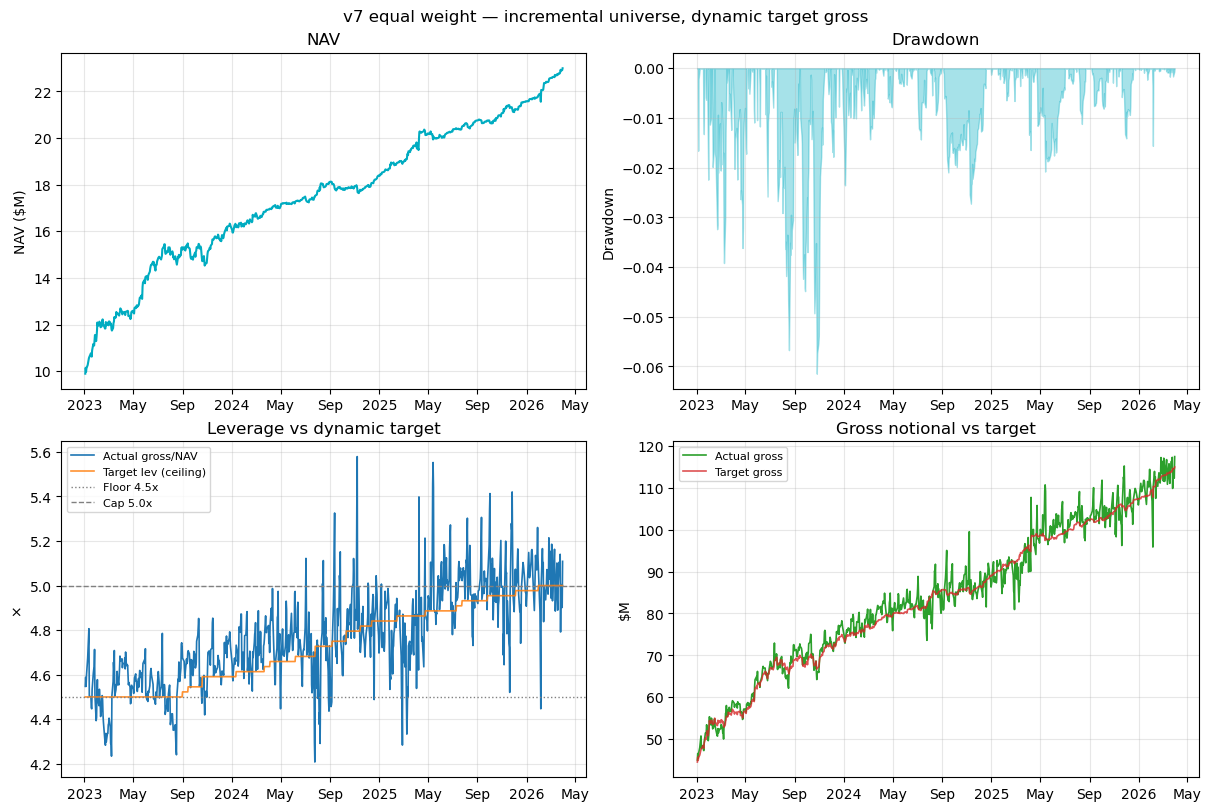

In [86]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
bt = ALL_BT[ref]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
fig.suptitle("v7 equal weight — incremental universe, dynamic target gross")

ax = axes[0, 0]
ax.plot(bt.index, bt["nav"] / 1e6, color="#00ACC1", lw=1.5)
ax.set_ylabel("NAV ($M)"); ax.set_title("NAV"); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
nav = bt["nav"]
dd = (nav - nav.cummax()) / nav.cummax()
ax.fill_between(dd.index, dd, 0, alpha=0.35, color="#00ACC1")
ax.set_ylabel("Drawdown"); ax.set_title("Drawdown"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(bt.index, bt["actual_leverage"], label="Actual gross/NAV", color="tab:blue", lw=1.2)
ax.plot(bt.index, bt["target_lev"], label="Target lev (ceiling)", color="tab:orange", lw=1.2, alpha=0.85)
ax.axhline(V7_TARGET_LEV_START, color="gray", ls=":", lw=1, label=f"Floor {V7_TARGET_LEV_START}x")
ax.axhline(V7_TARGET_LEV_END, color="gray", ls="--", lw=1, label=f"Cap {V7_TARGET_LEV_END}x")
ax.set_ylabel("×"); ax.set_title("Leverage vs dynamic target"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(bt.index, bt["gross_notional"] / 1e6, label="Actual gross", color="tab:green", lw=1.2)
ax.plot(bt.index, bt["tgt_gross_nav"] / 1e6, label="Target gross", color="tab:red", lw=1.2, alpha=0.8)
ax.set_ylabel("$M"); ax.set_title("Gross notional vs target"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


,pair,pnl,borrow_paid,net_pnl_after_borrow,avg_gross,ratio,ratio_net
16,NVDA/NVDL,9.769669e+06,0.000000,9.769669e+06,2.709473e+07,0.360575,0.360575
12,COIN/CONL,1.654620e+06,142518.125079,1.512102e+06,4.379218e+06,0.377835,0.345290
17,META/FBL,1.504730e+06,-60048.553440,1.564779e+06,5.555101e+06,0.270874,0.281683
15,AMZN/AMZU,1.573580e+06,-18655.513316,1.592235e+06,6.904941e+06,0.227892,0.230594
10,TSLA/TSLL,2.126509e+06,96361.540495,2.030147e+06,8.902163e+06,0.238876,0.228051
19,NVDA/NVDU,1.406818e+06,0.000000,1.406818e+06,6.335263e+06,0.222062,0.222062
22,IBIT/BITX,1.221705e+06,0.000000,1.221705e+06,6.150309e+06,0.198641,0.198641
14,MSFT/MSFU,8.447289e+05,-24260.085688,8.689889e+05,4.504246e+06,0.187541,0.192927
26,ETHA/ETHU,1.331586e+06,-87124.925026,1.418710e+06,7.877290e+06,0.169041,0.180101
13,GOOGL/GGLL,7.891882e+05,0.000000,7.891882e+05,4.394599e+06,0.179581,0.179581


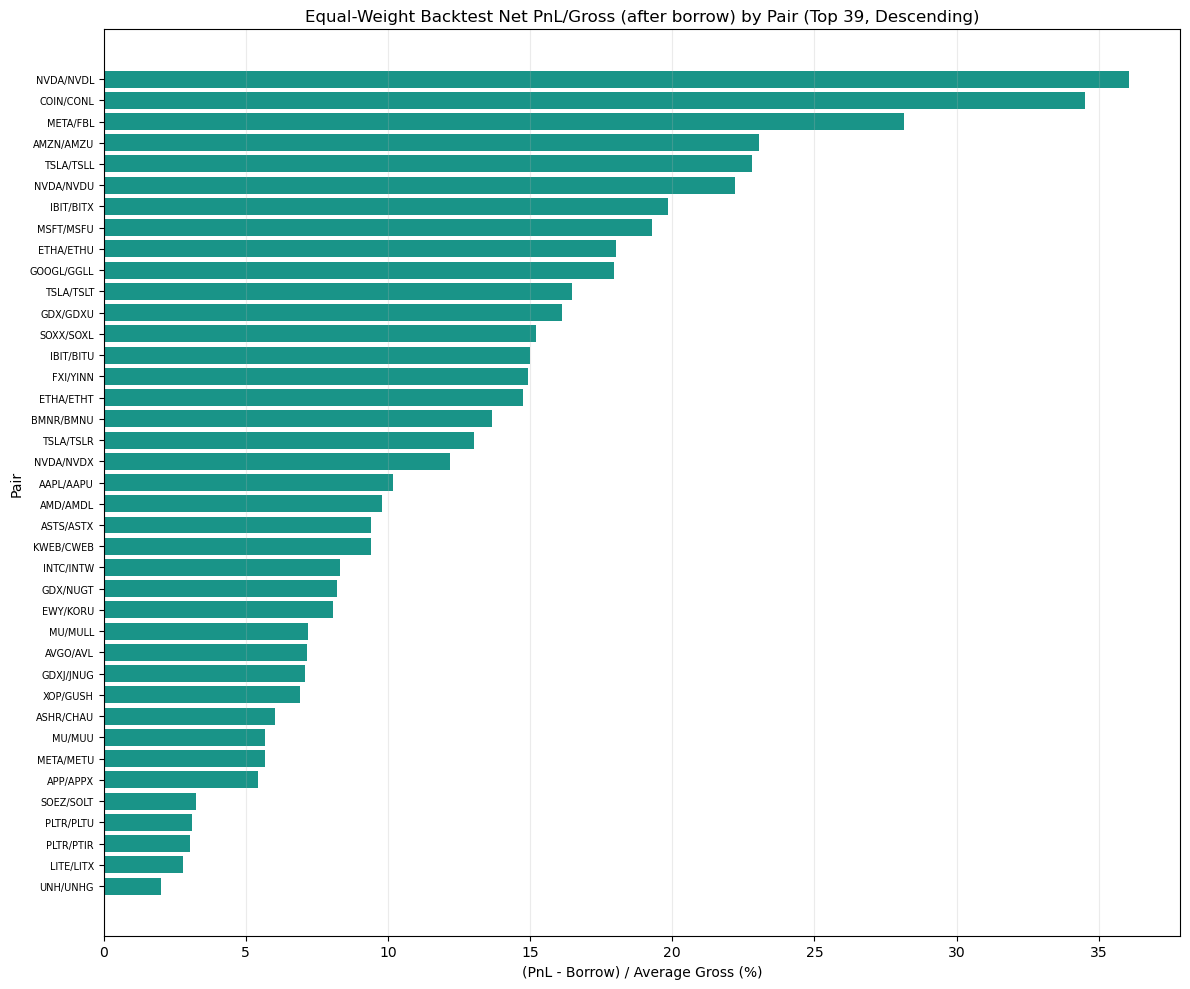

In [87]:
# ---- EW diagnostic: PnL/Gross by pair (descending) ----
import matplotlib.pyplot as plt

# Use saved EW objects when available; otherwise derive from ALL_*.
if "EW_PAIR_PNL" in globals() and "EW_PAIR_GROSS" in globals() and "ref_lev" in globals():
    _ppnl = EW_PAIR_PNL[ref_lev]
    _pgross = EW_PAIR_GROSS[ref_lev]
    _pborrow = EW_PAIR_BORROW[ref_lev] if "EW_PAIR_BORROW" in globals() and ref_lev in EW_PAIR_BORROW else {}
elif "ALL_PAIR_PNL" in globals() and "ALL_PAIR_GROSS" in globals() and "LEVERAGE_RUNS" in globals():
    _ref = max(LEVERAGE_RUNS)
    _ppnl = ALL_PAIR_PNL[_ref]
    _pgross = ALL_PAIR_GROSS[_ref]
    _pborrow = ALL_PAIR_BORROW[_ref] if "ALL_PAIR_BORROW" in globals() and _ref in ALL_PAIR_BORROW else {}
else:
    raise RuntimeError("Run the equal-weight backtest cells first (missing pair PnL/Gross objects).")

rows = []
for etf, d in _ppnl.items():
    pair = f"{d['und']}/{etf}"
    total_pnl = float(d.get("long", 0.0)) + float(d.get("short", 0.0))
    borrow_paid = float(_pborrow.get(etf, 0.0))
    net_pnl = total_pnl - borrow_paid
    avg_gross = float(_pgross[pair].mean()) if pair in _pgross.columns else np.nan
    ratio = total_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else np.nan
    ratio_net = net_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else np.nan
    rows.append({
        "pair": pair,
        "pnl": total_pnl,
        "borrow_paid": borrow_paid,
        "net_pnl_after_borrow": net_pnl,
        "avg_gross": avg_gross,
        "ratio": ratio,
        "ratio_net": ratio_net,
    })

pnl_gross_df = pd.DataFrame(rows)
pnl_gross_df = pnl_gross_df[pnl_gross_df["ratio_net"].notna()].copy()
if pnl_gross_df.empty:
    raise RuntimeError("No valid net PnL/Gross ratios found.")

pnl_gross_df.sort_values("ratio_net", ascending=False, inplace=True)
display(pnl_gross_df.head(30))

plot_n = min(120, len(pnl_gross_df))
plot_df = pnl_gross_df.head(plot_n).sort_values("ratio_net", ascending=True)

fig_h = min(40, max(10, 0.18 * plot_n))
fig, ax = plt.subplots(figsize=(12, fig_h))
ax.barh(plot_df["pair"], 100 * plot_df["ratio_net"], color="#00897B", alpha=0.9)
ax.set_title(f"Equal-Weight Backtest Net PnL/Gross (after borrow) by Pair (Top {plot_n}, Descending)")
ax.set_xlabel("(PnL - Borrow) / Average Gross (%)")
ax.set_ylabel("Pair")
ax.grid(axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()


## v8 Diamond Creek Fund Weights (PnL/Gross + NET Decay + Shares Cap)

Saves the **equal-weight** run to `EW_*`, writes **`data/backtest/v8_pnl_decay_shares_weights.csv`**, and then re-runs the same engine with those `PAIR_WEIGHTS` loaded as the **Diamond Creek Fund** sizing profile.

Construction summary:
- `PnL/Gross` component from the equal-weight v8 run
- `decay` component from `data/etf_screened_today.csv` using `decay_score`
- convex blend using `CFG['mix_decay_weight']`
- shares-availability capacity cap from `shares_available` and `CFG['short_avail_use_pct']`
- cap-ramp schedule: constrained names step up over `CFG['cap_ramp_rebals']` rebalances toward max allowed weight


In [88]:
# ---- Sample-book optimizer: PnL/Gross + NET Decay + Shares Cap ----

EW_BT = dict(ALL_BT)
EW_PAIR_PNL = dict(ALL_PAIR_PNL)
EW_PAIR_BORROW = dict(ALL_PAIR_BORROW) if "ALL_PAIR_BORROW" in globals() else {}
EW_PAIR_NET = dict(ALL_PAIR_NET)
EW_PAIR_GROSS = dict(ALL_PAIR_GROSS)

out = Path("data/backtest")
out.mkdir(parents=True, exist_ok=True)
for lev in LEVERAGE_RUNS:
    EW_BT[lev].to_csv(out / f"v8_ew_nav_{lev}x.csv")
print("Equal-weight v8 NAV series saved.")

ref_lev = max(LEVERAGE_RUNS)
ppnl = EW_PAIR_PNL[ref_lev]
ppair_borrow = EW_PAIR_BORROW.get(ref_lev, {}) if "EW_PAIR_BORROW" in globals() else {}
pgross = EW_PAIR_GROSS[ref_lev]

pnl_gross = {}
for etf, d in ppnl.items():
    total_pnl = float(d.get("long", 0.0)) + float(d.get("short", 0.0))
    pair_borrow_paid = float(ppair_borrow.get(etf, 0.0))
    net_pnl_after_borrow = total_pnl - pair_borrow_paid
    col = f"{d['und']}/{etf}"
    avg_gross = float(pgross[col].mean()) if col in pgross.columns else np.nan
    ratio = total_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else 0.0
    ratio_net = net_pnl_after_borrow / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else 0.0
    pnl_gross[etf] = {
        "und": d["und"],
        "pnl": total_pnl,
        "pair_borrow_paid": pair_borrow_paid,
        "net_pnl_after_borrow": net_pnl_after_borrow,
        "avg_gross": avg_gross,
        "ratio": ratio,
        "ratio_net": ratio_net,
    }

# ---- Load screener decay + shares available ----
screened_path = Path("../data/etf_screened_today.csv")
if not screened_path.exists():
    run_files = sorted(Path("data/runs").glob("*/etf_screened_today.csv"))
    if not run_files:
        raise FileNotFoundError("Could not find data/etf_screened_today.csv or data/runs/*/etf_screened_today.csv")
    screened_path = run_files[-1]

screen = pd.read_csv(screened_path)
screen.columns = [str(c).strip() for c in screen.columns]
if "ETF" not in screen.columns:
    raise KeyError("Screener file must include an ETF column")

screen["ETF"] = screen["ETF"].astype(str).str.upper()

decay_col = "decay_score"
if decay_col not in screen.columns:
    raise KeyError("Screener file missing required decay_score column")

screen[decay_col] = pd.to_numeric(screen[decay_col], errors="coerce").fillna(0.0)
if "net_decay_annual" in screen.columns:
    screen["net_decay_annual"] = pd.to_numeric(screen["net_decay_annual"], errors="coerce").fillna(0.0)
else:
    screen["net_decay_annual"] = np.nan

if "shares_available" in screen.columns:
    screen["shares_available"] = pd.to_numeric(screen["shares_available"], errors="coerce")
else:
    screen["shares_available"] = np.nan

# Optional AUM inputs (USD). Prefer explicit AUM, then AUM_M, then vendor asset fields.
if "AUM" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["AUM"], errors="coerce")
elif "AUM_M" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["AUM_M"], errors="coerce") * 1e6
elif "totalAssets" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["totalAssets"], errors="coerce")
elif "netAssets" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["netAssets"], errors="coerce")
else:
    screen["aum_usd"] = np.nan

screen["aum_usd"] = pd.to_numeric(screen["aum_usd"], errors="coerce")
screen.loc[screen["aum_usd"] <= 0, "aum_usd"] = np.nan
screen["aum_source"] = np.where(screen["aum_usd"].notna(), "screen", "missing")

# Backfill missing AUM from yfinance with a local cache.
missing_aum = screen["aum_usd"].isna()
if missing_aum.any():
    try:
        import yfinance as yf

        aum_cache_path = Path("data/backtest/etf_aum_cache.csv")
        aum_cache_path.parent.mkdir(parents=True, exist_ok=True)
        if aum_cache_path.exists():
            aum_cache = pd.read_csv(aum_cache_path)
            if not {"ETF", "aum_usd"}.issubset(aum_cache.columns):
                aum_cache = pd.DataFrame(columns=["ETF", "aum_usd"])
        else:
            aum_cache = pd.DataFrame(columns=["ETF", "aum_usd"])

        if not aum_cache.empty:
            aum_cache["ETF"] = aum_cache["ETF"].astype(str).str.upper().str.strip()
            aum_cache["aum_usd"] = pd.to_numeric(aum_cache["aum_usd"], errors="coerce")
            cache_map = dict(zip(aum_cache["ETF"], aum_cache["aum_usd"]))
            from_cache = screen["ETF"].map(cache_map)
            use_cache = missing_aum & from_cache.notna() & (from_cache > 0)
            screen.loc[use_cache, "aum_usd"] = from_cache[use_cache]
            screen.loc[use_cache, "aum_source"] = "cache"

        still_missing = screen["aum_usd"].isna()
        if still_missing.any():
            fetch_syms = sorted(screen.loc[still_missing, "ETF"].dropna().astype(str).str.upper().unique())
            fetched = []
            for t in fetch_syms:
                q = t.replace(".", "-")
                val = np.nan
                try:
                    tk = yf.Ticker(q)
                    fi = getattr(tk, "fast_info", {}) or {}
                    if isinstance(fi, dict):
                        for k in ("total_assets", "totalAssets", "net_assets", "netAssets", "market_cap", "marketCap"):
                            v = fi.get(k)
                            if v is not None and pd.notna(v) and float(v) > 0:
                                val = float(v)
                                break
                    if pd.isna(val):
                        info = tk.info or {}
                        for k in ("totalAssets", "netAssets", "fundAssets", "marketCap"):
                            v = info.get(k)
                            if v is not None and pd.notna(v) and float(v) > 0:
                                val = float(v)
                                break
                except Exception:
                    pass

                if pd.notna(val) and val > 0:
                    fetched.append((t, float(val)))

            if fetched:
                fetched_df = pd.DataFrame(fetched, columns=["ETF", "aum_usd"])
                fetch_map = dict(zip(fetched_df["ETF"], fetched_df["aum_usd"]))
                from_fetch = screen["ETF"].map(fetch_map)
                use_fetch = screen["aum_usd"].isna() & from_fetch.notna() & (from_fetch > 0)
                screen.loc[use_fetch, "aum_usd"] = from_fetch[use_fetch]
                screen.loc[use_fetch, "aum_source"] = "yfinance"

                aum_cache = pd.concat([aum_cache, fetched_df], ignore_index=True)
                aum_cache = aum_cache.dropna(subset=["ETF"]).copy()
                aum_cache["ETF"] = aum_cache["ETF"].astype(str).str.upper().str.strip()
                aum_cache["aum_usd"] = pd.to_numeric(aum_cache["aum_usd"], errors="coerce")
                aum_cache = aum_cache[aum_cache["aum_usd"].notna() & (aum_cache["aum_usd"] > 0)]
                aum_cache = aum_cache.drop_duplicates(subset=["ETF"], keep="last").sort_values("ETF")
                aum_cache.to_csv(aum_cache_path, index=False)
    except Exception:
        pass

# Historical average shares_available by ticker (mean over each ticker's observed days).
runs_candidates = [
    Path("../data/runs"),
    Path("data/runs"),
    Path.cwd() / "../data/runs",
    Path.cwd() / "data/runs",
    Path.cwd().parent / "data/runs",
]
runs_root = None
for cand in runs_candidates:
    c = cand.resolve()
    if c.exists():
        runs_root = c
        break

shares_hist = []
if runs_root is not None:
    run_files = sorted(runs_root.glob("*/etf_screened_today.csv"))
    for rf in run_files:
        try:
            d = pd.read_csv(rf)
        except Exception:
            continue
        if "ETF" not in d.columns:
            continue
        d["ETF"] = d["ETF"].astype(str).str.upper()
        if "shares_available" in d.columns:
            d["shares_available"] = pd.to_numeric(d["shares_available"], errors="coerce")
        else:
            d["shares_available"] = np.nan
        d = d[["ETF", "shares_available"]].rename(columns={"ETF": "etf"})
        d["run_date"] = rf.parent.name
        shares_hist.append(d)

if shares_hist:
    sh = pd.concat(shares_hist, ignore_index=True)
    sh_agg = (
        sh.groupby("etf", dropna=False)["shares_available"]
        .agg(shares_available_avg="mean", shares_obs="count")
        .reset_index()
    )
    sh_agg["shares_obs"] = sh_agg["shares_obs"].astype(int)
    screen = screen.merge(sh_agg, left_on="ETF", right_on="etf", how="left")
    screen.drop(columns=["etf"], inplace=True)
else:
    screen["shares_available_avg"] = np.nan
    screen["shares_obs"] = 0

screen["shares_obs"] = pd.to_numeric(screen.get("shares_obs"), errors="coerce").fillna(0).astype(int)
screen["shares_available_for_cap"] = np.where(
    screen["shares_obs"] > 0,
    screen["shares_available_avg"],
    screen["shares_available"],
)

# Historical average borrow by ticker across data/runs snapshots.
borrow_hist = []
borrow_col_priority = ["borrow_net_annual", "borrow_current", "borrow_fee_annual"]
if runs_root is not None:
    snapshot_files = []
    for d in sorted(runs_root.glob("*")):
        if not d.is_dir():
            continue
        f_screen = d / "etf_screened_today.csv"
        f_trades = d / "proposed_trades.csv"
        if f_screen.exists():
            snapshot_files.append(f_screen)
        elif f_trades.exists():
            snapshot_files.append(f_trades)

    for p in [Path("data/etf_screened_today.csv"), Path("../data/etf_screened_today.csv")]:
        if p.exists():
            snapshot_files.append(p)
            break

    for rf in snapshot_files:
        try:
            d = pd.read_csv(rf)
        except Exception:
            continue
        if "ETF" not in d.columns:
            continue
        col = next((c for c in borrow_col_priority if c in d.columns), None)
        if col is None:
            continue
        b = d[["ETF", col]].copy()
        b["ETF"] = b["ETF"].astype(str).str.upper().str.strip()
        b["borrow_rate"] = pd.to_numeric(b[col], errors="coerce")
        b = b[b["ETF"].ne("") & b["borrow_rate"].notna()]
        b = b[np.isfinite(b["borrow_rate"])].copy()
        borrow_hist.append(b[["ETF", "borrow_rate"]])

if borrow_hist:
    bh = pd.concat(borrow_hist, ignore_index=True)

    def _trimmed_mean_drop2(s: pd.Series) -> float:
        x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
        if len(x) <= 4:
            return float(x.mean()) if len(x) else np.nan
        return float(x.iloc[2:-2].mean())

    bh_mean = bh.groupby("ETF")["borrow_rate"].apply(_trimmed_mean_drop2).rename("borrow_avg_annual")
    bh_obs = bh.groupby("ETF")["borrow_rate"].size().rename("borrow_obs")
    bh_agg = pd.concat([bh_mean, bh_obs], axis=1).reset_index()
    screen = screen.merge(bh_agg, on="ETF", how="left")
else:
    screen["borrow_avg_annual"] = np.nan
    screen["borrow_obs"] = 0

for c in ["borrow_current", "borrow_net_annual", "blended_gross_decay", "expected_gross_decay_annual", "gross_decay_annual"]:
    if c in screen.columns:
        screen[c] = pd.to_numeric(screen[c], errors="coerce")
    else:
        screen[c] = np.nan

screen["borrow_avg_annual"] = pd.to_numeric(screen.get("borrow_avg_annual"), errors="coerce")
screen["borrow_obs"] = pd.to_numeric(screen.get("borrow_obs"), errors="coerce").fillna(0).astype(int)

# v10 sample-book mode: use ONLY spreadsheet net borrow for optimization.
if "SAMPLE_BOOK_BORROW_MAP" in globals() and isinstance(SAMPLE_BOOK_BORROW_MAP, dict) and SAMPLE_BOOK_BORROW_MAP:
    _sample_map = {str(k).upper(): float(v) for k, v in SAMPLE_BOOK_BORROW_MAP.items()}
    screen["borrow_for_weight"] = screen["ETF"].map(_sample_map)
    _miss = int(screen["borrow_for_weight"].isna().sum())
    if _miss:
        screen["borrow_for_weight"] = screen["borrow_for_weight"].fillna(float(CFG.get("fallback_borrow_rate", 0.02)))
        print(f"[weights] sample-book borrow missing for {_miss} ETFs; fallback applied")
else:
    # Fallback behavior if sample-book borrow is unavailable.
    screen["borrow_for_weight"] = (
        screen["borrow_avg_annual"]
        .combine_first(screen["borrow_current"])
        .combine_first(screen["borrow_net_annual"])
        .fillna(float(CFG.get("fallback_borrow_rate", 0.02)))
    )

# Adapted from daily_screener: decay_score = blended_gross_decay - borrow.
# In v10 sample-book mode, borrow comes directly from spreadsheet net borrow.
screen["gross_decay_for_weight"] = (
    screen["blended_gross_decay"]
    .combine_first(screen["expected_gross_decay_annual"])
    .combine_first(screen["gross_decay_annual"])
)
screen["decay_score_hist_borrow"] = np.where(
    screen["gross_decay_for_weight"].notna(),
    screen["gross_decay_for_weight"] - screen["borrow_for_weight"],
    np.nan,
)

# Final non-NA AUM fill: underlying median, then global median.
known_aum = screen.loc[screen["aum_usd"].notna() & (screen["aum_usd"] > 0), "aum_usd"]
global_med_aum = float(known_aum.median()) if len(known_aum) else np.nan

if "Underlying" in screen.columns:
    und_med = (
        screen.loc[screen["aum_usd"].notna() & (screen["aum_usd"] > 0)]
        .groupby("Underlying", dropna=False)["aum_usd"]
        .median()
    )
    und_fill = screen["Underlying"].map(und_med)
    use_und = screen["aum_usd"].isna() & und_fill.notna() & (und_fill > 0)
    screen.loc[use_und, "aum_usd"] = und_fill[use_und]
    screen.loc[use_und, "aum_source"] = "underlying_median"

if pd.notna(global_med_aum) and global_med_aum > 0:
    use_global = screen["aum_usd"].isna()
    screen.loc[use_global, "aum_usd"] = global_med_aum
    screen.loc[use_global, "aum_source"] = "global_median"

# Hard fallback to avoid NA in reporting tables.
use_zero = screen["aum_usd"].isna()
if use_zero.any():
    screen.loc[use_zero, "aum_usd"] = 0.0
    screen.loc[use_zero, "aum_source"] = "fallback_zero"

screen["aum_usd"] = pd.to_numeric(screen["aum_usd"], errors="coerce").fillna(0.0)

decay_col = "decay_score_hist_borrow"

screener_map = screen.set_index("ETF")[[
    decay_col,
    "gross_decay_for_weight",
    "borrow_for_weight",
    "borrow_avg_annual",
    "borrow_obs",
    "net_decay_annual",
    "shares_available",
    "shares_available_avg",
    "shares_available_for_cap",
    "shares_obs",
    "aum_usd",
    "aum_source",
]].to_dict("index")

pw = CFG.get("weight_power", 2)
decay_pw = CFG.get("decay_weight_power", 1.25)
mix_decay = float(CFG.get("mix_decay_weight", 0.45))
mix_decay = min(1.0, max(0.0, mix_decay))

etfs = sorted(pnl_gross.keys())
pnl_component = pd.Series({etf: max(0.0, pnl_gross[etf]["ratio_net"]) ** pw for etf in etfs}, dtype=float)
decay_component = pd.Series(
    {etf: max(0.0, float(screener_map.get(etf, {}).get(decay_col, 0.0))) ** decay_pw for etf in etfs},
    dtype=float,
)

if pnl_component.sum() <= 0:
    pnl_component[:] = 1.0
if decay_component.sum() <= 0:
    decay_component[:] = 1.0

pnl_norm = pnl_component / pnl_component.sum()
decay_norm = decay_component / decay_component.sum()
combined_signal = (1.0 - mix_decay) * pnl_norm + mix_decay * decay_norm
raw_weight = combined_signal / combined_signal.sum()

ranked = sorted(etfs, key=lambda e: float(combined_signal.get(e, 0.0)), reverse=True)

# Optional concentration tilt: increase allocation to largest signals.
conc_pw = float(CFG.get("position_concentration_power", 1.0))
if conc_pw > 1.0:
    raw_weight = raw_weight.pow(conc_pw)
    if raw_weight.sum() > 0:
        raw_weight = raw_weight / raw_weight.sum()

# ---- Capacity caps from shares_available ----
beta_map = {etf: abs(bv) for etf, _, bv in UNIVERSE}
ref_date = EW_BT[ref_lev].index[-1]
ref_tgt_gross = float(EW_BT[ref_lev]["tgt_gross_nav"].iloc[-1])
short_avail_use_pct = float(CFG.get("short_avail_use_pct", 0.10))
max_pair_weight_cap = float(CFG.get("max_pair_weight_cap", 0.10))
max_underlying_weight_cap = float(CFG.get("max_underlying_weight_cap", 0.20))
missing_shares_cap = float(CFG.get("missing_shares_cap", 0.01))

# For table translation from weights -> dollars.
assumed_nav_usd = float(CFG.get("capital_usd", 10_000_000))
assumed_target_lev = float(EW_BT[ref_lev]["target_lev"].iloc[-1]) if "target_lev" in EW_BT[ref_lev].columns else float(V7_TARGET_LEV_END)
assumed_target_gross_usd = assumed_nav_usd * assumed_target_lev

cap_frac = {}
for etf in etfs:
    babs = max(1e-9, beta_map.get(etf, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)

    px_ser = PRICES.get(etf)
    px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan
    sh_av = screener_map.get(etf, {}).get("shares_available_for_cap", np.nan)

    if pd.isna(sh_av) or sh_av <= 0 or pd.isna(px_e) or px_e <= 0:
        cap = missing_shares_cap
    else:
        cap_shares = float(sh_av) * short_avail_use_pct
        cap = (cap_shares * px_e) / max(1.0, ref_tgt_gross * short_frac)

    cap_frac[etf] = min(max_pair_weight_cap, max(0.0, cap))

cap_s = pd.Series(cap_frac, dtype=float)

# If strict caps are infeasible, minimally relax toward desired weights.
if cap_s.sum() < 1.0:
    cap_s = np.maximum(cap_s, raw_weight)


def project_to_capped_simplex(desired: pd.Series, caps: pd.Series, tol: float = 1e-12) -> pd.Series:
    """Project desired weights onto {w>=0, w<=caps, sum(w)=1}.

    This keeps final weights <= caps whenever feasible.
    """
    desired = desired.astype(float).copy()
    caps = caps.astype(float).copy().clip(lower=0.0)

    if desired.sum() <= 0:
        desired[:] = 1.0
    desired = desired / desired.sum()

    # Ensure feasibility (sum caps must be >= 1).
    if caps.sum() < 1.0:
        caps = np.maximum(caps, desired)

    w = pd.Series(0.0, index=desired.index)
    free = list(desired.index)
    remaining = 1.0

    while free and remaining > tol:
        base = desired.loc[free]
        if base.sum() <= 0:
            trial = pd.Series(remaining / len(free), index=free)
        else:
            trial = remaining * base / base.sum()

        hit = trial > (caps.loc[free] + tol)
        if not hit.any():
            w.loc[free] = trial
            remaining = 0.0
            break

        hit_idx = list(trial.index[hit])
        w.loc[hit_idx] = caps.loc[hit_idx]
        remaining = 1.0 - float(w.sum())
        free = [k for k in free if k not in hit_idx]

    # Safety: fill any tiny remainder by available headroom.
    if remaining > tol and free:
        room = (caps.loc[free] - w.loc[free]).clip(lower=0.0)
        if room.sum() > tol:
            w.loc[free] += remaining * room / room.sum()

    w = w.clip(lower=0.0)
    if w.sum() <= 0:
        w = desired.copy()

    w = w / w.sum()
    w = np.minimum(w, caps)

    # Final small renorm without violating caps.
    rem = 1.0 - float(w.sum())
    if rem > tol:
        room = (caps - w).clip(lower=0.0)
        if room.sum() > tol:
            w += rem * room / room.sum()
    if w.sum() > 0:
        w = w / w.sum()
    return w


final_weight_pair = project_to_capped_simplex(raw_weight, cap_s)
und_s = pd.Series({etf: str(pnl_gross.get(etf, {}).get("und", "UNKNOWN")) for etf in etfs}, dtype="object")


def project_to_pair_and_underlying_caps(
    desired: pd.Series,
    pair_caps: pd.Series,
    und_map: pd.Series,
    underlying_cap: float,
    tol: float = 1e-12,
    max_iter: int = 200,
) -> pd.Series:
    """Project desired weights onto:
    - per-pair caps:     0 <= w_i <= pair_caps_i
    - per-underlying cap: sum_{i in underlying} w_i <= underlying_cap
    - budget: sum_i w_i = 1
    """
    w = desired.astype(float).copy().clip(lower=0.0)
    pair_caps = pair_caps.astype(float).copy().clip(lower=0.0)
    und_map = und_map.reindex(w.index).fillna("UNKNOWN").astype(str)

    if w.sum() <= 0:
        w[:] = 1.0
    w = w / w.sum()

    for _ in range(max_iter):
        prev = w.copy()

        # Enforce per-pair caps first.
        w = np.minimum(w, pair_caps)

        # Enforce per-underlying caps by proportional scaling within each violating underlying.
        und_tot = w.groupby(und_map).sum()
        over = und_tot[und_tot > underlying_cap + tol]
        for und, tot in over.items():
            idx = und_map[und_map == und].index
            if tot > 0:
                w.loc[idx] *= float(underlying_cap / tot)

        # Refill remaining budget only into names with both pair and underlying headroom.
        rem = 1.0 - float(w.sum())
        if rem > tol:
            und_tot = w.groupby(und_map).sum()
            und_head = (underlying_cap - und_tot).clip(lower=0.0)
            name_und_head = und_map.map(und_head).astype(float)
            pair_head = (pair_caps - w).clip(lower=0.0)
            name_head = np.minimum(pair_head, name_und_head)
            hs = float(name_head.sum())
            if hs > tol:
                w += rem * (name_head / hs)

        w = w.clip(lower=0.0)
        if w.sum() > 0:
            w = w / w.sum()

        # Stop when updates are negligible.
        if float(np.max(np.abs((w - prev).values))) < 1e-10:
            break

    return w


final_weight = project_to_pair_and_underlying_caps(
    final_weight_pair,
    cap_s,
    und_s,
    max_underlying_weight_cap,
)
weights_dict = final_weight.to_dict()

print(f"Using screener: {screened_path}")
if runs_root is not None:
    print(f"Shares-average history root: {runs_root}")
print(
    f"Signal: net pnl/gross (after pair borrow) + (gross_decay - avg_borrow) | decay column: {decay_col} | mix_decay_weight={mix_decay:.2f} | "
    f"weight_power={pw} | decay_weight_power={decay_pw} | concentration_power={conc_pw:.2f}"
)
print(
    f"Borrow source for weighting: historical average where available "
    f"(tickers with history: {(screen['borrow_obs'] > 0).sum()}/{len(screen)})"
)
print(
    f"Shares cap: use={short_avail_use_pct:.1%}, hard pair cap={max_pair_weight_cap:.1%}, "
    f"hard underlying cap={max_underlying_weight_cap:.1%}, missing_shares_cap={missing_shares_cap:.1%}"
)
print(
    f"Shares source for cap: per-ticker historical mean where available "
    f"(tickers with history: {(screen['shares_obs'] > 0).sum()}/{len(screen)})"
)
print(
    f"Dollar translation assumptions: NAV=${assumed_nav_usd:,.0f}, "
    f"target gross={assumed_target_lev:.2f}x -> ${assumed_target_gross_usd:,.0f}"
)
print(
    f"AUM availability after fill: {screen['aum_usd'].notna().sum()}/{len(screen)} tickers | "
    f"sources: screen={(screen['aum_source']=='screen').sum()}, cache={(screen['aum_source']=='cache').sum()}, "
    f"yfinance={(screen['aum_source']=='yfinance').sum()}, underlying_med={(screen['aum_source']=='underlying_median').sum()}, "
    f"global_med={(screen['aum_source']=='global_median').sum()}, zero_fallback={(screen['aum_source']=='fallback_zero').sum()}"
)
print(f"Top 5 concentration: {sum(sorted(weights_dict.values(), reverse=True)[:5]):.1%}")
print(f"Top 10 concentration: {sum(sorted(weights_dict.values(), reverse=True)[:10]):.1%}")
_und_w_chk = pd.Series(weights_dict).groupby(und_s).sum()
print(f"Max underlying concentration: {_und_w_chk.max():.1%} (cap {max_underlying_weight_cap:.1%})")

w_rows = []
for etf in ranked:
    d = pnl_gross.get(etf, {"und": None, "pnl": 0.0, "pair_borrow_paid": 0.0, "net_pnl_after_borrow": 0.0, "avg_gross": np.nan, "ratio": 0.0, "ratio_net": 0.0})

    sh_cur = screener_map.get(etf, {}).get("shares_available", np.nan)
    sh_avg = screener_map.get(etf, {}).get("shares_available_avg", np.nan)
    sh_cap = screener_map.get(etf, {}).get("shares_available_for_cap", np.nan)
    sh_obs_raw = screener_map.get(etf, {}).get("shares_obs", 0)
    sh_obs = int(sh_obs_raw) if pd.notna(sh_obs_raw) else 0

    dcol_val = float(screener_map.get(etf, {}).get(decay_col, 0.0))
    nd_val = float(screener_map.get(etf, {}).get("net_decay_annual", np.nan))
    gross_decay_val = float(screener_map.get(etf, {}).get("gross_decay_for_weight", np.nan))
    borrow_w_val = float(screener_map.get(etf, {}).get("borrow_for_weight", np.nan))
    borrow_avg_val = float(screener_map.get(etf, {}).get("borrow_avg_annual", np.nan))
    borrow_obs_raw = screener_map.get(etf, {}).get("borrow_obs", 0)
    borrow_obs_val = int(borrow_obs_raw) if pd.notna(borrow_obs_raw) else 0

    aum_usd = float(screener_map.get(etf, {}).get("aum_usd", np.nan))
    aum_source = str(screener_map.get(etf, {}).get("aum_source", "missing"))

    babs = max(1e-9, beta_map.get(etf, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)
    px_ser = PRICES.get(etf)
    px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan

    pair_target_gross_usd = float(weights_dict.get(etf, 0.0)) * assumed_target_gross_usd
    short_target_usd = pair_target_gross_usd * short_frac
    max_short_capacity_usd_full = (float(sh_cap) * float(px_e)) if (pd.notna(sh_cap) and pd.notna(px_e) and sh_cap > 0 and px_e > 0) else np.nan
    max_short_capacity_usd_used = (
        float(sh_cap) * short_avail_use_pct * float(px_e)
        if (pd.notna(sh_cap) and pd.notna(px_e) and sh_cap > 0 and px_e > 0)
        else np.nan
    )

    w_rows.append(
        {
            "etf": etf,
            "und": d["und"],
            "pnl": d["pnl"],
            "pair_borrow_paid": d["pair_borrow_paid"],
            "net_pnl_after_borrow": d["net_pnl_after_borrow"],
            "avg_gross": d["avg_gross"],
            "ratio": d["ratio"],
            "ratio_net": d["ratio_net"],
            "decay_col": decay_col,
            "decay_value": dcol_val,
            "gross_decay_for_weight": gross_decay_val,
            "borrow_for_weight": borrow_w_val,
            "borrow_avg_annual": borrow_avg_val,
            "borrow_obs": borrow_obs_val,
            "net_decay_annual": nd_val,
            "shares_available": sh_cur,
            "shares_available_avg": sh_avg,
            "shares_available_for_cap": sh_cap,
            "shares_obs": sh_obs,
            "aum_usd": aum_usd,
            "aum_m": aum_usd / 1e6 if pd.notna(aum_usd) else np.nan,
            "aum_source": aum_source,
            "etf_price": px_e,
            "short_frac": short_frac,
            "pair_target_gross_usd": pair_target_gross_usd,
            "short_target_usd": short_target_usd,
            "max_short_capacity_usd_full": max_short_capacity_usd_full,
            "max_short_capacity_usd_used": max_short_capacity_usd_used,
            "short_capacity_utilization": (short_target_usd / max_short_capacity_usd_used) if (pd.notna(max_short_capacity_usd_used) and max_short_capacity_usd_used > 0) else np.nan,
            "pnl_component": float(pnl_component.get(etf, 0.0)),
            "decay_component": float(decay_component.get(etf, 0.0)),
            "combined_signal": float(combined_signal.get(etf, 0.0)),
            "weight_raw": float(raw_weight.get(etf, 0.0)),
            "weight_cap": float(cap_s.get(etf, 0.0)),
            "weight": float(weights_dict.get(etf, 0.0)),
            "cap_binding": int(final_weight.get(etf, 0.0) >= cap_s.get(etf, 0.0) - 1e-9),
        }
    )

w_df = pd.DataFrame(w_rows)
if not w_df.empty:
    _und_tot = w_df.groupby("und", dropna=False)["weight"].sum().rename("underlying_total_weight")
    w_df = w_df.merge(_und_tot, left_on="und", right_index=True, how="left")
weights_file_v10 = out / "v10_sample_pnl_decay_borrow_weights.csv"
weights_file_legacy = out / "v8_pnl_decay_shares_weights.csv"
w_df.to_csv(weights_file_v10, index=False)
# Keep legacy filename for backward compatibility with older cells/scripts.
w_df.to_csv(weights_file_legacy, index=False)
print(f"Saved {len(w_df)} pair weights to {weights_file_v10.name} (and legacy {weights_file_legacy.name})")

print("\nv8 Diamond Creek Fund weighting (PnL/Gross + decay, capped by shares availability)")
print(
    f"{'Rank':>4s}  {'Pair':>18s}  {'Final W':>8s}  {'AUM($M)':>9s}  {'AUM Src':>9s}  {'ETF Px':>8s}  {'Shares(avg)':>12s}  {'Obs':>4s}  "
    f"{'Short$@10m':>11s}  {'ShAvg*Px$':>11s}  {'Use%Cap$':>11s}  {'Util':>7s}"
)
print(f"  {'-'*161}")
for i, row in enumerate(w_df.sort_values("weight", ascending=False).itertuples(index=False), 1):
    pair = f"{row.und}/{row.etf}"
    aum_txt = "NA" if pd.isna(row.aum_m) else f"{row.aum_m:,.0f}"
    aum_src_txt = str(row.aum_source)[:9]
    px_txt = "NA" if pd.isna(row.etf_price) else f"{row.etf_price:,.2f}"
    sh_txt = "NA" if pd.isna(row.shares_available_for_cap) else f"{row.shares_available_for_cap:,.0f}"
    short_txt = "NA" if pd.isna(row.short_target_usd) else f"{row.short_target_usd:,.0f}"
    full_cap_txt = "NA" if pd.isna(row.max_short_capacity_usd_full) else f"{row.max_short_capacity_usd_full:,.0f}"
    use_cap_txt = "NA" if pd.isna(row.max_short_capacity_usd_used) else f"{row.max_short_capacity_usd_used:,.0f}"
    util_txt = "NA" if pd.isna(row.short_capacity_utilization) else f"{row.short_capacity_utilization:,.0%}"
    print(
        f"  {i:3d}  {pair:>18s}  {row.weight:>7.2%}  {aum_txt:>9s}  {aum_src_txt:>9s}  {px_txt:>8s}  {sh_txt:>12s}  {int(row.shares_obs):>4d}  "
        f"{short_txt:>11s}  {full_cap_txt:>11s}  {use_cap_txt:>11s}  {util_txt:>7s}"
    )


Equal-weight v8 NAV series saved.
[weights] sample-book borrow missing for 348 ETFs; fallback applied
Using screener: ..\data\etf_screened_today.csv
Shares-average history root: C:\Users\werdn\Documents\Investing\ls-algo\data\runs
Signal: net pnl/gross (after pair borrow) + (gross_decay - avg_borrow) | decay column: decay_score_hist_borrow | mix_decay_weight=0.45 | weight_power=2 | decay_weight_power=1.25 | concentration_power=1.35
Borrow source for weighting: historical average where available (tickers with history: 384/388)
Shares cap: use=25.0%, hard pair cap=10.0%, hard underlying cap=20.0%, missing_shares_cap=3.0%
Shares source for cap: per-ticker historical mean where available (tickers with history: 388/388)
Dollar translation assumptions: NAV=$10,000,000, target gross=5.00x -> $50,000,000
AUM availability after fill: 388/388 tickers | sources: screen=0, cache=358, yfinance=0, underlying_med=17, global_med=13, zero_fallback=0
Top 5 concentration: 36.6%
Top 10 concentration: 57.3

In [89]:
# ---- Re-run weighted backtest now (using newly built PnL/Gross weights) ----
# This bridge executes the existing weighted-run + metrics cells so results appear directly below.

import json
from pathlib import Path

if "w_df" not in globals() or w_df is None or len(w_df) == 0:
    raise RuntimeError("Run the Sample-book optimizer cell first (w_df missing).")

# Ensure the latest weights are active for downstream weighted run.
PAIR_WEIGHTS = dict(zip(w_df["etf"].astype(str).str.upper(), pd.to_numeric(w_df["weight"], errors="coerce").fillna(0.0)))
PAIR_WEIGHTS = {k: float(v) for k, v in PAIR_WEIGHTS.items() if v > 0}
if not PAIR_WEIGHTS:
    raise RuntimeError("No positive PAIR_WEIGHTS found in w_df.")

print(f"[RUN] Using PnL/Gross-derived weights for {len(PAIR_WEIGHTS)} ETFs")

# Execute the existing weighted run and performance cells (keeps one source of truth).
nb_path = Path("notebooks/Diamond_Creek_Backtest_v10.ipynb")
if not nb_path.exists():
    nb_path = Path("Diamond_Creek_Backtest_v10.ipynb")
if not nb_path.exists():
    raise FileNotFoundError("Could not locate Diamond_Creek_Backtest_v10.ipynb")

with nb_path.open("r", encoding="utf-8") as f:
    nb_obj = json.load(f)

for idx in (30, 31):
    src = nb_obj["cells"][idx]["source"]
    code = "".join(src) if isinstance(src, list) else str(src)
    exec(code, globals(), globals())

print("[RUN] Weighted backtest + performance metrics complete.")

[RUN] Using PnL/Gross-derived weights for 39 ETFs

Diamond Creek Fund — Top 8 absolute daily NAV moves
2023-05-25  NAV ret=+3.99%  NAV pnl=$+522,391
2023-02-02  NAV ret=+3.07%  NAV pnl=$+360,683
2023-01-04  NAV ret=+2.56%  NAV pnl=$+253,403
2023-01-20  NAV ret=+2.56%  NAV pnl=$+271,581
2023-01-23  NAV ret=+2.50%  NAV pnl=$+272,624
2025-04-09  NAV ret=+2.41%  NAV pnl=$+469,510
2026-02-06  NAV ret=+2.35%  NAV pnl=$+506,206
2023-08-21  NAV ret=+2.29%  NAV pnl=$+333,451

Diamond Creek Fund — Pair attribution on jump days (approx, lag gross × spread return)
------------------------------------------------------------------------------

2023-05-25  NAV ret=+3.99%  NAV pnl=$+522,391
         NVDA/NVDL  contrib=$+453,447
         MSFT/MSFU  contrib=$+31,554
        GOOGL/GGLL  contrib=$+13,791
         TSLA/TSLL  contrib=$+13,029
          META/FBL  contrib=$+9,207

2023-02-02  NAV ret=+3.07%  NAV pnl=$+360,683
          META/FBL  contrib=$+89,191
         COIN/CONL  contrib=$+80,272
         

,month,benchmark_rate_avg,benchmark_rate_eom,avg_gross_lev,long_trading_pnl,short_trading_pnl,net_trading_pnl,interest_income,margin_interest_paid,net_interest_carry,borrow_fees_paid,txn_costs_paid,net_pnl,trading_pct_of_net,carry_pct_of_net,borrow_pct_of_net,residual_pnl
0,2023-01,0.043200,0.0432,4.578141,7.379938e+06,-5.720292e+06,1.659647e+06,46363.465703,86267.180668,-39903.714965,5096.817339,131603.084941,1.587727e+06,1.045297,-0.025133,-0.003210,1.046839e+05
1,2023-02,0.045568,0.0457,4.426332,7.954642e+05,-1.332419e+05,6.622224e+05,52143.759240,99821.926177,-47678.166937,5299.476941,4779.102039,6.044656e+05,1.095550,-0.078877,-0.008767,3.510650e-10
2,2023-03,0.046448,0.0482,4.515882,4.223728e+06,-3.520194e+06,7.035338e+05,67469.106194,129726.754005,-62257.647811,6572.924677,27061.001894,6.076423e+05,1.157809,-0.102458,-0.010817,1.168519e-08
3,2023-04,0.048184,0.0481,4.605577,-1.249809e+06,1.180370e+06,-6.943869e+04,59145.521089,117955.474304,-58809.953214,5902.967990,3523.179071,-1.376748e+05,0.504368,0.427166,0.042876,-2.219167e-09
4,2023-05,0.050332,0.0507,4.578321,4.507683e+06,-3.207358e+06,1.300324e+06,75338.442280,148485.134965,-73146.692686,5702.982615,5774.085228,1.215700e+06,1.069609,-0.060168,-0.004691,2.750312e-09
5,2023-06,0.050629,0.0507,4.538263,3.705797e+06,-2.656673e+06,1.049123e+06,79293.409563,160795.226888,-81501.817325,7104.934230,21939.347641,9.385773e+05,1.117780,-0.086835,-0.007570,1.746230e-09
6,2023-07,0.051065,0.0532,4.536699,3.551797e+06,-2.845547e+06,7.062500e+05,80478.132613,163866.282773,-83388.150160,7806.175382,16821.743471,5.982339e+05,1.180558,-0.139391,-0.013049,-1.256558e-08
7,2023-08,0.053165,0.0532,4.480740,-9.827006e+05,1.114468e+06,1.317677e+05,93415.662863,189891.926285,-96476.263422,8349.747062,16759.813161,1.018190e+04,12.941368,-9.475270,-0.820058,4.547474e-09
8,2023-09,0.053190,0.0532,4.645973,-2.854338e+06,2.592582e+06,-2.617556e+05,85198.068643,175544.582746,-90346.514103,7682.556941,13114.008782,-3.728987e+05,0.701948,0.242282,0.020602,-2.088200e-09
9,2023-10,0.053200,0.0532,4.610476,-2.087680e+06,1.911355e+06,-1.763254e+05,92923.438539,189876.665250,-96953.226711,7838.081084,18622.994839,-2.997397e+05,0.588262,0.323458,0.026150,9.531504e-10



Cumulative attribution summary


,portfolio,net_trading_pnl,net_interest_carry,borrow_fees_paid,txn_costs_paid,net_pnl,trading_pct_of_net,carry_pct_of_net,borrow_pct_of_net
0,Diamond Creek Fund,1.900947e+07,-4.107409e+06,321195.095303,1.589278e+06,1.309627e+07,1.451518,-0.313632,-0.024526


[RUN] Weighted backtest + performance metrics complete.


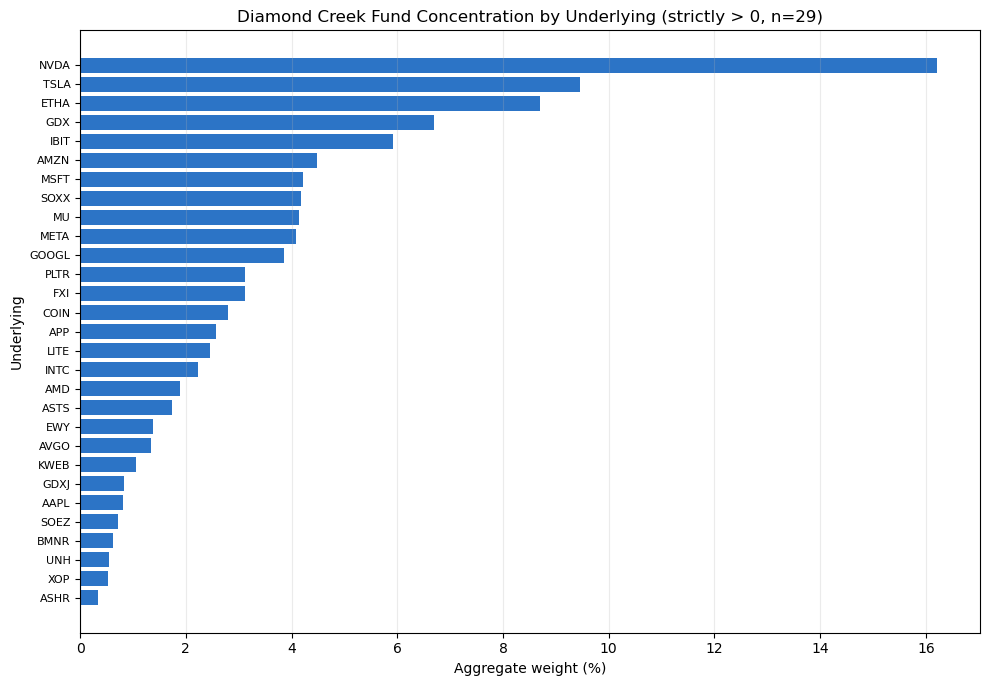

In [90]:

import matplotlib.pyplot as plt

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the Diamond Creek weighting cell first (w_df not found).")

und_w = (
    w_df.loc[w_df["weight"] > 0, ["und", "weight"]]
    .groupby("und", as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=True)
)

if und_w.empty:
    raise RuntimeError("No strictly positive weights found for underlying concentration.")

n = len(und_w)
fig_h = min(24, max(6, 0.24 * n))
fig, ax = plt.subplots(figsize=(10, fig_h))

ax.barh(und_w["und"], und_w["weight"] * 100.0, color="#1565C0", alpha=0.9)
ax.set_title(f"Diamond Creek Fund Concentration by Underlying (strictly > 0, n={n})")
ax.set_xlabel("Aggregate weight (%)")
ax.set_ylabel("Underlying")
ax.grid(True, axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


## Performance — Diamond Creek Fund weighted


In [91]:
ref = max(LEVERAGE_RUNS)

for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]
    nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  v8 Diamond Creek Fund — {lev}x (store key)")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")



  v8 Diamond Creek Fund — 4.5x (store key)
  CAGR                :         29.86%
  Vol                 :          9.58%
  Sharpe              :        311.82%
  Sortino             :        464.39%
  Max DD              :         -6.14%
  Calmar              :        486.01%
  Monthly Win%        :          84.2%
  Final NAV           : $    22,991,591
  P&L                 : $    13,096,274
  Txn Costs           : $     1,589,278
  Borrow Costs        : $       321,195
  Margin Debit        : $     7,757,011
  Long P&L            : $    81,284,930
  Short P&L           : $   -62,275,458


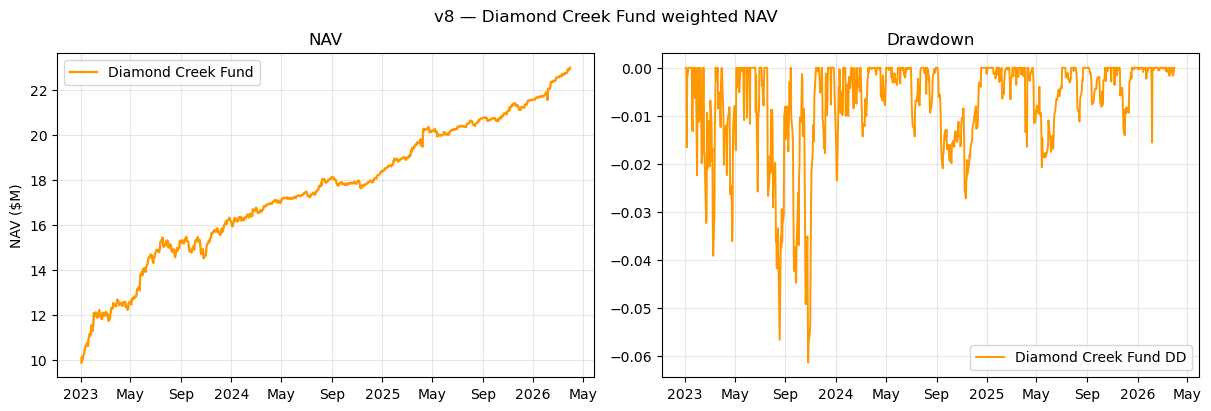

In [92]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.suptitle("v8 — Diamond Creek Fund weighted NAV")

dc_nav = ALL_BT[ref]["nav"]
ax = axes[0]
ax.plot(dc_nav.index, dc_nav / 1e6, label="Diamond Creek Fund", color="#FF9800", lw=1.7)
ax.set_ylabel("NAV ($M)")
ax.set_title("NAV")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
dd_dc = (dc_nav - dc_nav.cummax()) / dc_nav.cummax()
ax.plot(dd_dc.index, dd_dc, label="Diamond Creek Fund DD", color="#FF9800", lw=1.4)
ax.set_title("Drawdown")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


## NAV Jump Attribution (Diamond Creek Fund)

Ranks the largest absolute daily NAV moves and estimates top pair-level contributors on those days using lagged pair gross and pair spread returns.


In [93]:
ref = max(LEVERAGE_RUNS)

if "UNIVERSE" not in globals() or len(UNIVERSE) == 0:
    if "CANDIDATES" in globals() and "INCEPTION" in globals():
        UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
        UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])
        print(f"[UNIVERSE] Rebuilt from CANDIDATES+INCEPTION: {len(UNIVERSE)} pairs")
    else:
        raise RuntimeError("Run universe setup cells first: CANDIDATES + INCEPTION/UNIVERSE are missing.")

beta_map = {e: abs(float(b)) for e, u, b in UNIVERSE}

def _build_pair_contrib_usd(pair_gross_df: pd.DataFrame) -> pd.DataFrame:
    if pair_gross_df is None or pair_gross_df.empty:
        return pd.DataFrame()

    idx = pair_gross_df.index
    contrib = pd.DataFrame(index=idx)

    for col in pair_gross_df.columns:
        if "/" not in col:
            continue
        und, etf = col.split("/", 1)
        if und not in PRICES or etf not in PRICES:
            continue

        pu = PRICES[und].reindex(idx).ffill()
        pe = PRICES[etf].reindex(idx).ffill()
        if pu.isna().all() or pe.isna().all():
            continue

        ru = pu.pct_change().fillna(0.0)
        re = pe.pct_change().fillna(0.0)

        babs = max(1e-9, beta_map.get(etf, 2.0))
        hr = 1.0 / babs
        long_frac = 1.0 / (1.0 + hr)
        short_frac = hr / (1.0 + hr)

        pair_ret = long_frac * ru - short_frac * re
        lag_gross = pair_gross_df[col].shift(1).fillna(0.0)
        contrib[col] = lag_gross * pair_ret

    return contrib


def _print_jump_attribution(label: str, bt: pd.DataFrame, pair_contrib: pd.DataFrame, top_n_days: int = 8, top_n_pairs: int = 5):
    nav = bt["nav"].astype(float)
    nav_ret = nav.pct_change().dropna()
    nav_pnl = nav.diff().fillna(0.0)

    top_days = nav_ret.abs().sort_values(ascending=False).head(top_n_days)

    print(f"\n{'='*78}")
    print(f"{label} — Top {top_n_days} absolute daily NAV moves")
    print(f"{'='*78}")
    for d in top_days.index:
        print(f"{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")

    print(f"\n{label} — Pair attribution on jump days (approx, lag gross × spread return)")
    print(f"{'-'*78}")
    for d in top_days.index:
        if d not in pair_contrib.index:
            continue
        c = pair_contrib.loc[d].dropna()
        if c.empty:
            continue
        top_pairs = c.reindex(c.abs().sort_values(ascending=False).head(top_n_pairs).index)

        print(f"\n{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")
        for pair, v in top_pairs.items():
            print(f"  {pair:>16s}  contrib=${v:+,.0f}")


dc_bt = ALL_BT[ref]
dc_contrib = _build_pair_contrib_usd(ALL_PAIR_GROSS[ref])

_print_jump_attribution("Diamond Creek Fund", dc_bt, dc_contrib)



Diamond Creek Fund — Top 8 absolute daily NAV moves
2023-05-25  NAV ret=+3.99%  NAV pnl=$+522,391
2023-02-02  NAV ret=+3.07%  NAV pnl=$+360,683
2023-01-04  NAV ret=+2.56%  NAV pnl=$+253,403
2023-01-20  NAV ret=+2.56%  NAV pnl=$+271,581
2023-01-23  NAV ret=+2.50%  NAV pnl=$+272,624
2025-04-09  NAV ret=+2.41%  NAV pnl=$+469,510
2026-02-06  NAV ret=+2.35%  NAV pnl=$+506,206
2023-08-21  NAV ret=+2.29%  NAV pnl=$+333,451

Diamond Creek Fund — Pair attribution on jump days (approx, lag gross × spread return)
------------------------------------------------------------------------------

2023-05-25  NAV ret=+3.99%  NAV pnl=$+522,391
         NVDA/NVDL  contrib=$+453,447
         MSFT/MSFU  contrib=$+31,554
        GOOGL/GGLL  contrib=$+13,791
         TSLA/TSLL  contrib=$+13,029
          META/FBL  contrib=$+9,207

2023-02-02  NAV ret=+3.07%  NAV pnl=$+360,683
          META/FBL  contrib=$+89,191
         COIN/CONL  contrib=$+80,272
         NVDA/NVDL  contrib=$+58,894
         TSLA/TSLL  co

In [94]:
# ---- Joel White Bay: Monthly P&L attribution (trading vs carry vs borrow) ----
ref = max(LEVERAGE_RUNS)


def _build_attribution(bt: pd.DataFrame, label: str, freq: str = "ME") -> pd.DataFrame:
    d = bt.copy().sort_index()

    # Flow components from cumulative series.
    d["long_trading_pnl"] = d["cum_long_pnl"].diff().fillna(d["cum_long_pnl"])
    d["short_trading_pnl"] = d["cum_short_pnl"].diff().fillna(d["cum_short_pnl"])
    d["net_trading_pnl"] = d["long_trading_pnl"] + d["short_trading_pnl"]

    d["interest_income"] = d["cum_margin_credit"].diff().fillna(d["cum_margin_credit"])
    d["margin_interest_paid"] = d["cum_margin_debit"].diff().fillna(d["cum_margin_debit"])
    d["net_interest_carry"] = d["interest_income"] - d["margin_interest_paid"]

    d["borrow_fees_paid"] = d["cum_borrow"].diff().fillna(d["cum_borrow"])
    d["txn_costs_paid"] = d["cum_costs"].diff().fillna(d["cum_costs"])

    d["net_pnl"] = d["nav"].diff().fillna(d["nav"] - d["nav"].iloc[0])

    # Robust gross leverage derivation across engine schema versions.
    if "actual_leverage" in d.columns:
        d["gross_lev"] = pd.to_numeric(d["actual_leverage"], errors="coerce")
    elif "gross_notional" in d.columns:
        d["gross_lev"] = (pd.to_numeric(d["gross_notional"], errors="coerce").abs() / d["nav"].replace(0, np.nan))
    elif {"long_notional", "short_notional"}.issubset(d.columns):
        d["gross_lev"] = (
            (pd.to_numeric(d["long_notional"], errors="coerce").abs() + pd.to_numeric(d["short_notional"], errors="coerce").abs())
            / d["nav"].replace(0, np.nan)
        )
    else:
        d["gross_lev"] = np.nan
    d["gross_lev"] = d["gross_lev"].replace([np.inf, -np.inf], np.nan)

    # Expected bridge from components; residual helps QA.
    d["explained_pnl"] = d["net_trading_pnl"] + d["net_interest_carry"] - d["borrow_fees_paid"] - d["txn_costs_paid"]
    d["residual_pnl"] = d["net_pnl"] - d["explained_pnl"]

    sum_cols = [
        "long_trading_pnl",
        "short_trading_pnl",
        "net_trading_pnl",
        "interest_income",
        "margin_interest_paid",
        "net_interest_carry",
        "borrow_fees_paid",
        "txn_costs_paid",
        "net_pnl",
        "explained_pnl",
        "residual_pnl",
    ]
    out = d[sum_cols].resample(freq).sum()
    out["avg_gross_lev"] = d["gross_lev"].resample(freq).mean()

    if "fed_funds_rate" in d.columns:
        rate = pd.to_numeric(d["fed_funds_rate"], errors="coerce")
        out["benchmark_rate_avg"] = rate.resample(freq).mean()
        out["benchmark_rate_eom"] = rate.resample(freq).last()
    else:
        out["benchmark_rate_avg"] = np.nan
        out["benchmark_rate_eom"] = np.nan

    # Contribution views.
    out["trading_pct_of_net"] = np.where(out["net_pnl"] != 0, out["net_trading_pnl"] / out["net_pnl"], np.nan)
    out["carry_pct_of_net"] = np.where(out["net_pnl"] != 0, out["net_interest_carry"] / out["net_pnl"], np.nan)
    out["borrow_pct_of_net"] = np.where(out["net_pnl"] != 0, -out["borrow_fees_paid"] / out["net_pnl"], np.nan)

    abs_driver = out["net_trading_pnl"].abs() + out["net_interest_carry"].abs() + out["borrow_fees_paid"].abs() + out["txn_costs_paid"].abs()
    out["trading_abs_share"] = np.where(abs_driver > 0, out["net_trading_pnl"].abs() / abs_driver, np.nan)
    out["carry_abs_share"] = np.where(abs_driver > 0, out["net_interest_carry"].abs() / abs_driver, np.nan)
    out["borrow_abs_share"] = np.where(abs_driver > 0, out["borrow_fees_paid"].abs() / abs_driver, np.nan)
    out["txn_abs_share"] = np.where(abs_driver > 0, out["txn_costs_paid"].abs() / abs_driver, np.nan)

    out.insert(0, "portfolio", label)
    out.insert(1, "month", out.index.strftime("%Y-%m"))
    return out.reset_index(drop=True)


monthly_dc = _build_attribution(ALL_BT[ref], "Diamond Creek Fund")
monthly_attr = pd.concat([monthly_dc], ignore_index=True)

print("=" * 108)
print("Monthly P&L Attribution — Trading vs Interest Carry vs Borrow")
print("=" * 108)
print(
    "Columns: net_trading_pnl, net_interest_carry (interest_income - margin_interest_paid), "
    "borrow_fees_paid, txn_costs_paid, net_pnl, avg_gross_lev, benchmark_rate_avg/eom"
)

for name in ["Diamond Creek Fund"]:
    x = monthly_attr[monthly_attr["portfolio"] == name].copy()
    print(f"\n{name} — monthly attribution")
    display(
        x[[
            "month",
            "benchmark_rate_avg",
            "benchmark_rate_eom",
            "avg_gross_lev",
            "long_trading_pnl",
            "short_trading_pnl",
            "net_trading_pnl",
            "interest_income",
            "margin_interest_paid",
            "net_interest_carry",
            "borrow_fees_paid",
            "txn_costs_paid",
            "net_pnl",
            "trading_pct_of_net",
            "carry_pct_of_net",
            "borrow_pct_of_net",
            "residual_pnl",
        ]]
    )

# Compact cumulative summary for fast readout.
summary = (
    monthly_attr.groupby("portfolio", dropna=False)[[
        "net_trading_pnl",
        "net_interest_carry",
        "borrow_fees_paid",
        "txn_costs_paid",
        "net_pnl",
    ]]
    .sum()
    .reset_index()
)
summary["trading_pct_of_net"] = np.where(summary["net_pnl"] != 0, summary["net_trading_pnl"] / summary["net_pnl"], np.nan)
summary["carry_pct_of_net"] = np.where(summary["net_pnl"] != 0, summary["net_interest_carry"] / summary["net_pnl"], np.nan)
summary["borrow_pct_of_net"] = np.where(summary["net_pnl"] != 0, -summary["borrow_fees_paid"] / summary["net_pnl"], np.nan)

print("\nCumulative attribution summary")
display(summary)

daily_attr_dc = ALL_BT[ref].copy()


Monthly P&L Attribution — Trading vs Interest Carry vs Borrow
Columns: net_trading_pnl, net_interest_carry (interest_income - margin_interest_paid), borrow_fees_paid, txn_costs_paid, net_pnl, avg_gross_lev, benchmark_rate_avg/eom

Diamond Creek Fund — monthly attribution


,month,benchmark_rate_avg,benchmark_rate_eom,avg_gross_lev,long_trading_pnl,short_trading_pnl,net_trading_pnl,interest_income,margin_interest_paid,net_interest_carry,borrow_fees_paid,txn_costs_paid,net_pnl,trading_pct_of_net,carry_pct_of_net,borrow_pct_of_net,residual_pnl
0,2023-01,0.043200,0.0432,4.578141,7.379938e+06,-5.720292e+06,1.659647e+06,46363.465703,86267.180668,-39903.714965,5096.817339,131603.084941,1.587727e+06,1.045297,-0.025133,-0.003210,1.046839e+05
1,2023-02,0.045568,0.0457,4.426332,7.954642e+05,-1.332419e+05,6.622224e+05,52143.759240,99821.926177,-47678.166937,5299.476941,4779.102039,6.044656e+05,1.095550,-0.078877,-0.008767,3.510650e-10
2,2023-03,0.046448,0.0482,4.515882,4.223728e+06,-3.520194e+06,7.035338e+05,67469.106194,129726.754005,-62257.647811,6572.924677,27061.001894,6.076423e+05,1.157809,-0.102458,-0.010817,1.168519e-08
3,2023-04,0.048184,0.0481,4.605577,-1.249809e+06,1.180370e+06,-6.943869e+04,59145.521089,117955.474304,-58809.953214,5902.967990,3523.179071,-1.376748e+05,0.504368,0.427166,0.042876,-2.219167e-09
4,2023-05,0.050332,0.0507,4.578321,4.507683e+06,-3.207358e+06,1.300324e+06,75338.442280,148485.134965,-73146.692686,5702.982615,5774.085228,1.215700e+06,1.069609,-0.060168,-0.004691,2.750312e-09
5,2023-06,0.050629,0.0507,4.538263,3.705797e+06,-2.656673e+06,1.049123e+06,79293.409563,160795.226888,-81501.817325,7104.934230,21939.347641,9.385773e+05,1.117780,-0.086835,-0.007570,1.746230e-09
6,2023-07,0.051065,0.0532,4.536699,3.551797e+06,-2.845547e+06,7.062500e+05,80478.132613,163866.282773,-83388.150160,7806.175382,16821.743471,5.982339e+05,1.180558,-0.139391,-0.013049,-1.256558e-08
7,2023-08,0.053165,0.0532,4.480740,-9.827006e+05,1.114468e+06,1.317677e+05,93415.662863,189891.926285,-96476.263422,8349.747062,16759.813161,1.018190e+04,12.941368,-9.475270,-0.820058,4.547474e-09
8,2023-09,0.053190,0.0532,4.645973,-2.854338e+06,2.592582e+06,-2.617556e+05,85198.068643,175544.582746,-90346.514103,7682.556941,13114.008782,-3.728987e+05,0.701948,0.242282,0.020602,-2.088200e-09
9,2023-10,0.053200,0.0532,4.610476,-2.087680e+06,1.911355e+06,-1.763254e+05,92923.438539,189876.665250,-96953.226711,7838.081084,18622.994839,-2.997397e+05,0.588262,0.323458,0.026150,9.531504e-10



Cumulative attribution summary


,portfolio,net_trading_pnl,net_interest_carry,borrow_fees_paid,txn_costs_paid,net_pnl,trading_pct_of_net,carry_pct_of_net,borrow_pct_of_net
0,Diamond Creek Fund,1.900947e+07,-4.107409e+06,321195.095303,1.589278e+06,1.309627e+07,1.451518,-0.313632,-0.024526


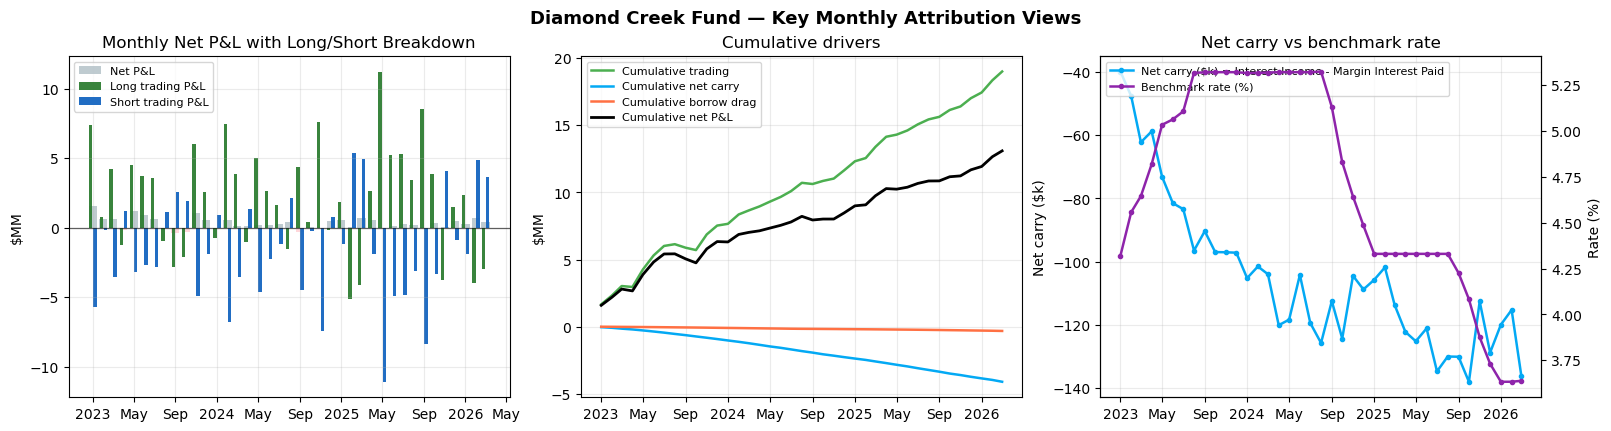

In [95]:
# ---- Joel White Bay: simplified visual attribution trends (monthly) ----
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "monthly_attr" not in globals() or monthly_attr.empty:
    raise RuntimeError("Run the monthly attribution cell first.")

m_dc = monthly_attr[monthly_attr["portfolio"] == "Diamond Creek Fund"].copy()
if m_dc.empty:
    raise RuntimeError("Missing Diamond Creek Fund attribution rows.")

m_dc["month_dt"] = pd.to_datetime(m_dc["month"] + "-01")
m_dc.sort_values("month_dt", inplace=True)

x = m_dc["month_dt"]
m_dc["borrow_drag"] = -m_dc["borrow_fees_paid"]

# Benchmark rate is flat when FRED download fails and fallback schedule is sparse.
rate = pd.to_numeric(m_dc.get("benchmark_rate_avg"), errors="coerce")
rate_pct = np.where(rate.abs().max() <= 1.0, rate * 100.0, rate)
if pd.Series(rate_pct).nunique(dropna=True) <= 2:
    print("Benchmark rate is nearly flat in this run (likely fallback rate series after FRED fetch failure).")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), layout="constrained")
fig.suptitle("Diamond Creek Fund — Key Monthly Attribution Views", fontsize=13, fontweight="bold")

# 1) Monthly net P&L with explicit long vs short trading breakdown.
ax = axes[0]
bar_wide = pd.Timedelta(days=24)
bar_narrow = pd.Timedelta(days=10)

# Wide background bar: total monthly net P&L.
net_colors = np.where(m_dc["net_pnl"] >= 0, "#B0BEC5", "#FFCDD2")
ax.bar(x, m_dc["net_pnl"] / 1e6, width=bar_wide, color=net_colors, alpha=0.8, label="Net P&L")

# Narrow bars: long/short trading legs (clear and side-by-side).
x_long = x - pd.to_timedelta(6, unit="D")
x_short = x + pd.to_timedelta(6, unit="D")
ax.bar(x_long, m_dc["long_trading_pnl"] / 1e6, width=bar_narrow, color="#2E7D32", alpha=0.95, label="Long trading P&L")
ax.bar(x_short, m_dc["short_trading_pnl"] / 1e6, width=bar_narrow, color="#1565C0", alpha=0.95, label="Short trading P&L")

ax.axhline(0, color="black", lw=0.9, alpha=0.6)
ax.set_title("Monthly Net P&L with Long/Short Breakdown")
ax.set_ylabel("$MM")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# 2) Keep this one as-is (most useful): cumulative drivers.
ax = axes[1]
ax.plot(x, m_dc["net_trading_pnl"].cumsum() / 1e6, label="Cumulative trading", color="#4CAF50", lw=1.8)
ax.plot(x, m_dc["net_interest_carry"].cumsum() / 1e6, label="Cumulative net carry", color="#03A9F4", lw=1.8)
ax.plot(x, m_dc["borrow_drag"].cumsum() / 1e6, label="Cumulative borrow drag", color="#FF7043", lw=1.8)
ax.plot(x, m_dc["net_pnl"].cumsum() / 1e6, label="Cumulative net P&L", color="black", lw=2.0)
ax.set_title("Cumulative drivers")
ax.set_ylabel("$MM")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# 3) Very simple carry-rate relationship.
ax = axes[2]
ax.plot(x, m_dc["net_interest_carry"] / 1e3, color="#03A9F4", lw=1.8, marker="o", ms=3, label="Net carry ($k) = Interest Income - Margin Interest Paid")
ax2 = ax.twinx()
ax2.plot(x, rate_pct, color="#8E24AA", lw=1.8, marker="o", ms=3, label="Benchmark rate (%)")
ax.set_title("Net carry vs benchmark rate")
ax.set_ylabel("Net carry ($k)")
ax2.set_ylabel("Rate (%)")
ax.grid(True, alpha=0.25)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

for _ax in axes:
    _ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(_ax.xaxis.get_major_locator()))

plt.show()


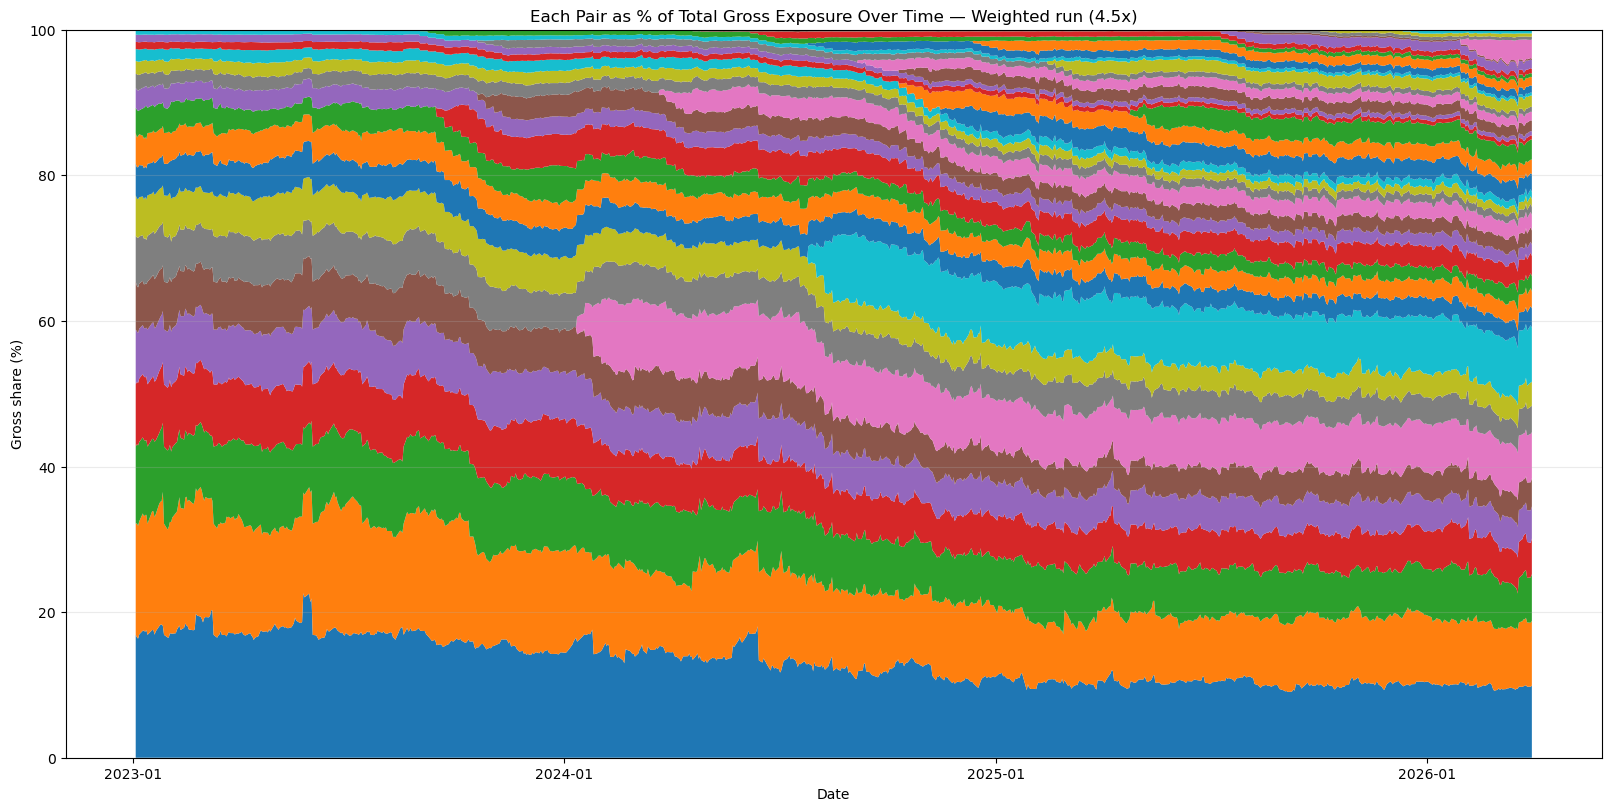

Pairs plotted: 40 | Date range: 2023-01-03 -> 2026-03-31
Top 15 pairs by average gross share (%):


,avg_gross_share_pct
NVDA/NVDL,13.217499
TSLA/TSLL,11.655046
GDX/GDXU,8.228671
SOXX/SOXL,6.556285
MSFT/MSFU,5.729681
GOOGL/GGLL,5.034951
IBIT/BITX,5.003966
FXI/YINN,4.738966
AMZN/AMZU,4.241310
ETHA/ETHU,4.116023


In [96]:
# ---- Pair gross share over time (% of total gross; each pair) ----
# Uses the most recent weighted run by default.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "ALL_PAIR_GROSS" in globals() and isinstance(ALL_PAIR_GROSS, dict) and len(ALL_PAIR_GROSS) > 0:
    ref_lev = max(ALL_PAIR_GROSS)
    gross_df = ALL_PAIR_GROSS[ref_lev].copy()
    run_label = f"Weighted run ({ref_lev}x)"
elif "EW_PAIR_GROSS" in globals() and isinstance(EW_PAIR_GROSS, dict) and len(EW_PAIR_GROSS) > 0:
    ref_lev = max(EW_PAIR_GROSS)
    gross_df = EW_PAIR_GROSS[ref_lev].copy()
    run_label = f"Equal-weight run ({ref_lev}x)"
else:
    raise RuntimeError("No pair gross time series found. Run a backtest cell first.")

if gross_df is None or gross_df.empty:
    raise RuntimeError("Pair gross time series is empty.")

# Ensure datetime index + numeric matrix.
gross_df = gross_df.copy()
gross_df.index = pd.to_datetime(gross_df.index)
gross_df = gross_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# % share of total gross exposure each day.
total_gross = gross_df.sum(axis=1).replace(0.0, np.nan)
pair_gross_pct = gross_df.div(total_gross, axis=0).fillna(0.0) * 100.0

# Sort pairs for a stable stacked ordering (largest average share at bottom).
pair_order = pair_gross_pct.mean(axis=0).sort_values(ascending=False).index.tolist()
pair_gross_pct = pair_gross_pct[pair_order]

fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")
ax.stackplot(pair_gross_pct.index, pair_gross_pct.T.values, linewidth=0)
ax.set_title(f"Each Pair as % of Total Gross Exposure Over Time — {run_label}")
ax.set_ylabel("Gross share (%)")
ax.set_xlabel("Date")
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(axis="y", alpha=0.25)
plt.show()

print(f"Pairs plotted: {pair_gross_pct.shape[1]} | Date range: {pair_gross_pct.index.min().date()} -> {pair_gross_pct.index.max().date()}")
print("Top 15 pairs by average gross share (%):")
display(pair_gross_pct.mean().sort_values(ascending=False).head(15).to_frame("avg_gross_share_pct"))

In [107]:
# ---- NVDA vs NVDL: daily closes, position, and long/short attribution ----

import numpy as np
import pandas as pd
from pathlib import Path

PAIR_UNDER = "NVDA"
PAIR_ETF = "NVDL"
PAIR_COL = f"{PAIR_UNDER}/{PAIR_ETF}"

# Prefer most recent weighted run; fallback to EW objects.
if "ALL_PAIR_GROSS" in globals() and isinstance(ALL_PAIR_GROSS, dict) and len(ALL_PAIR_GROSS) > 0:
    ref_lev = max(ALL_PAIR_GROSS)
    gross_df = ALL_PAIR_GROSS[ref_lev].copy()
    net_df = ALL_PAIR_NET[ref_lev].copy()
    bt_df = ALL_BT[ref_lev].copy() if "ALL_BT" in globals() and ref_lev in ALL_BT else None
    run_label = f"Weighted run ({ref_lev}x)"
elif "EW_PAIR_GROSS" in globals() and isinstance(EW_PAIR_GROSS, dict) and len(EW_PAIR_GROSS) > 0:
    ref_lev = max(EW_PAIR_GROSS)
    gross_df = EW_PAIR_GROSS[ref_lev].copy()
    net_df = EW_PAIR_NET[ref_lev].copy()
    bt_df = EW_BT[ref_lev].copy() if "EW_BT" in globals() and ref_lev in EW_BT else None
    run_label = f"Equal-weight run ({ref_lev}x)"
else:
    raise RuntimeError("No pair gross/net series found. Run backtest cells first.")

if PAIR_COL not in gross_df.columns or PAIR_COL not in net_df.columns:
    raise KeyError(f"Pair column {PAIR_COL} not found in pair net/gross tables.")
if bt_df is None or bt_df.empty:
    raise RuntimeError("Backtest daily table (ALL_BT/EW_BT) missing for cost allocation.")
if "PRICES" not in globals() or PAIR_UNDER not in PRICES or PAIR_ETF not in PRICES:
    raise RuntimeError("PRICES missing NVDA/NVDL. Run price download/setup cells first.")

idx = pd.to_datetime(gross_df.index)
idx = idx.sort_values().unique()

# Daily closes aligned to backtest dates.
close_under = PRICES[PAIR_UNDER].reindex(idx).ffill().astype(float)
close_etf = PRICES[PAIR_ETF].reindex(idx).ffill().astype(float)

pair_gross = pd.to_numeric(gross_df[PAIR_COL], errors="coerce").reindex(idx).fillna(0.0)
pair_net = pd.to_numeric(net_df[PAIR_COL], errors="coerce").reindex(idx).fillna(0.0)

# From gross/net decomposition:
# long_notional - short_notional = net
# long_notional + short_notional = gross
long_notional = ((pair_gross + pair_net) / 2.0).clip(lower=0.0)
short_notional = ((pair_gross - pair_net) / 2.0).clip(lower=0.0)

# Implied shares (continuous). Backtest trades are integer shares, so these can be fractional.
implied_long_sh = np.where(close_under > 0, long_notional / close_under, np.nan)
implied_short_sh = np.where(close_etf > 0, -short_notional / close_etf, np.nan)

# Daily attribution using lagged exposure and simple close-to-close returns.
ret_under = close_under.pct_change().fillna(0.0)
ret_etf = close_etf.pct_change().fillna(0.0)
lag_long = long_notional.shift(1).fillna(0.0)
lag_short = short_notional.shift(1).fillna(0.0)

daily_long_pnl = lag_long * ret_under
daily_short_pnl = -lag_short * ret_etf
daily_pair_gross_trading_pnl = daily_long_pnl + daily_short_pnl

# Allocate portfolio costs to this pair.
# - Transaction + borrow: by lagged gross share of portfolio gross.
# - Financing split: margin debit by lagged long share; short-credit income by lagged short share.
bt = bt_df.copy().reindex(idx)
lag_pair_gross = pair_gross.shift(1).fillna(0.0)
lag_total_gross = pd.to_numeric(bt.get("gross_notional", pd.Series(index=idx, dtype=float)), errors="coerce").fillna(0.0).shift(1).fillna(0.0)
pair_gross_share = np.where(lag_total_gross > 0, lag_pair_gross / lag_total_gross, 0.0)

lag_total_long = pd.to_numeric(bt.get("long_notional", pd.Series(index=idx, dtype=float)), errors="coerce").fillna(0.0).shift(1).fillna(0.0)
lag_total_short = pd.to_numeric(bt.get("short_notional", pd.Series(index=idx, dtype=float)), errors="coerce").fillna(0.0).shift(1).fillna(0.0)

cum_costs = pd.to_numeric(bt.get("cum_costs", pd.Series(index=idx, dtype=float)), errors="coerce").fillna(0.0)
cum_borrow = pd.to_numeric(bt.get("cum_borrow", pd.Series(index=idx, dtype=float)), errors="coerce").fillna(0.0)
cum_margin_debit = pd.to_numeric(bt.get("cum_margin_debit", pd.Series(index=idx, dtype=float)), errors="coerce").fillna(0.0)
cum_margin_credit = pd.to_numeric(bt.get("cum_margin_credit", pd.Series(index=idx, dtype=float)), errors="coerce").fillna(0.0)

daily_txn_total = cum_costs.diff().fillna(cum_costs)
daily_borrow_total = cum_borrow.diff().fillna(cum_borrow)
daily_margin_debit_total = cum_margin_debit.diff().fillna(cum_margin_debit)
daily_margin_credit_total = cum_margin_credit.diff().fillna(cum_margin_credit)

pair_alloc_txn_cost = pair_gross_share * daily_txn_total
pair_alloc_borrow_cost = pair_gross_share * daily_borrow_total
pair_alloc_margin_debit_cost = np.where(lag_total_long > 0, lag_long / lag_total_long * daily_margin_debit_total, 0.0)
pair_alloc_short_credit_income = np.where(lag_total_short > 0, lag_short / lag_total_short * daily_margin_credit_total, 0.0)
pair_alloc_net_financing_cost = pair_alloc_margin_debit_cost - pair_alloc_short_credit_income
pair_alloc_total_cost = pair_alloc_txn_cost + pair_alloc_borrow_cost + pair_alloc_net_financing_cost

daily_pair_net_pnl = daily_pair_gross_trading_pnl - pair_alloc_total_cost

out = pd.DataFrame({
    "date": idx,
    "close_nvda": close_under.values,
    "close_nvdl": close_etf.values,
    "long_notional_usd": long_notional.values,
    "short_notional_usd": short_notional.values,
    "pair_gross_usd": pair_gross.values,
    "pair_net_usd": pair_net.values,
    "implied_long_sh_nvda": implied_long_sh,
    "implied_short_sh_nvdl": implied_short_sh,
    "ret_nvda": ret_under.values,
    "ret_nvdl": ret_etf.values,
    "daily_long_pnl_usd": daily_long_pnl.values,
    "daily_short_pnl_usd": daily_short_pnl.values,
    "daily_pair_gross_trading_pnl_usd": daily_pair_gross_trading_pnl.values,
    "pair_gross_share_of_portfolio": pair_gross_share,
    "daily_pair_alloc_txn_cost_usd": pair_alloc_txn_cost.values,
    "daily_pair_alloc_borrow_cost_usd": pair_alloc_borrow_cost.values,
    "daily_pair_alloc_margin_debit_cost_usd": pair_alloc_margin_debit_cost,
    "daily_pair_alloc_short_credit_income_usd": pair_alloc_short_credit_income,
    "daily_pair_alloc_net_financing_cost_usd": pair_alloc_net_financing_cost,
    "daily_pair_alloc_total_cost_usd": pair_alloc_total_cost.values,
    "daily_pair_net_pnl_usd": daily_pair_net_pnl.values,
})

# Backward-compatible alias for previous column naming.
out["daily_pair_pnl_usd"] = out["daily_pair_gross_trading_pnl_usd"]

out["cum_long_pnl_usd"] = out["daily_long_pnl_usd"].cumsum()
out["cum_short_pnl_usd"] = out["daily_short_pnl_usd"].cumsum()
out["cum_pair_gross_trading_pnl_usd"] = out["daily_pair_gross_trading_pnl_usd"].cumsum()
out["cum_pair_alloc_margin_debit_cost_usd"] = out["daily_pair_alloc_margin_debit_cost_usd"].cumsum()
out["cum_pair_alloc_short_credit_income_usd"] = out["daily_pair_alloc_short_credit_income_usd"].cumsum()
out["cum_pair_alloc_net_financing_cost_usd"] = out["daily_pair_alloc_net_financing_cost_usd"].cumsum()
out["cum_pair_alloc_total_cost_usd"] = out["daily_pair_alloc_total_cost_usd"].cumsum()
out["cum_pair_net_pnl_usd"] = out["daily_pair_net_pnl_usd"].cumsum()

# Backward-compatible alias.
out["cum_pair_pnl_usd"] = out["cum_pair_gross_trading_pnl_usd"]

print(f"{PAIR_COL} | {run_label} | rows={len(out)}")
print(
    f"Final cumulative gross trading PnL=${out['cum_pair_gross_trading_pnl_usd'].iloc[-1]:,.0f}, "
    f"txn costs=${out['daily_pair_alloc_txn_cost_usd'].sum():,.0f}, "
    f"borrow=${out['daily_pair_alloc_borrow_cost_usd'].sum():,.0f}, "
    f"margin debit=${out['cum_pair_alloc_margin_debit_cost_usd'].iloc[-1]:,.0f}, "
    f"short credit=${out['cum_pair_alloc_short_credit_income_usd'].iloc[-1]:,.0f}, "
    f"net financing=${out['cum_pair_alloc_net_financing_cost_usd'].iloc[-1]:,.0f}, "
    f"allocated costs=${out['cum_pair_alloc_total_cost_usd'].iloc[-1]:,.0f}, "
    f"net pair PnL=${out['cum_pair_net_pnl_usd'].iloc[-1]:,.0f}"
)

# Full daily table requested.
display(out)

# Save for audit/export.
out_path = Path("data/backtest") / f"daily_pair_attribution_{PAIR_UNDER}_{PAIR_ETF}.csv"
out.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

NVDA/NVDL | Weighted run (4.5x) | rows=813
Final cumulative gross trading PnL=$4,101,937, txn costs=$182,725, borrow=$41,633, margin debit=$964,551, short credit=$500,527, net financing=$464,023, allocated costs=$688,382, net pair PnL=$3,413,555


,date,close_nvda,close_nvdl,long_notional_usd,short_notional_usd,pair_gross_usd,pair_net_usd,implied_long_sh_nvda,implied_short_sh_nvdl,ret_nvda,...,daily_pair_pnl_usd,cum_long_pnl_usd,cum_short_pnl_usd,cum_pair_gross_trading_pnl_usd,cum_pair_alloc_margin_debit_cost_usd,cum_pair_alloc_short_credit_income_usd,cum_pair_alloc_net_financing_cost_usd,cum_pair_alloc_total_cost_usd,cum_pair_net_pnl_usd,cum_pair_pnl_usd
0,2023-01-03,14.299909,2.885449,5.053116e+06,2.541809e+06,7.594925e+06,2.511307e+06,353367.0,-880906.0,0.000000,...,0.000000,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
1,2023-01-04,14.733451,2.842647,5.206315e+06,2.504105e+06,7.710420e+06,2.702211e+06,353367.0,-880906.0,0.030318,...,190904.147479,1.531995e+05,3.770462e+04,1.909041e+05,676.092358,413.854727,262.237631,301.584749,1.906026e+05,1.909041e+05
2,2023-01-05,14.249964,2.711843,5.035467e+06,2.388879e+06,7.424346e+06,2.646588e+06,353367.0,-880906.0,-0.032816,...,-55622.943518,-1.764887e+04,1.529301e+05,1.352812e+05,1332.121146,789.935818,542.185329,620.042013,1.346612e+05,1.352812e+05
3,2023-01-06,14.843338,2.874824,5.245146e+06,2.638404e+06,7.883550e+06,2.606742e+06,353367.0,-917762.0,0.041640,...,66108.749374,1.920300e+05,9.359945e+03,2.013900e+05,2005.572903,1179.421248,826.151655,1193.788331,2.001962e+05,2.013900e+05
4,2023-01-09,15.611526,3.111436,5.516598e+06,2.855558e+06,8.372156e+06,2.661040e+06,353367.0,-917762.0,0.051753,...,54298.223796,4.634825e+05,-2.077943e+05,2.556882e+05,2713.502051,1608.325826,1105.176224,1516.631950,2.541715e+05,2.556882e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
808,2026-03-25,178.679993,76.739998,7.639284e+06,3.953645e+06,1.159293e+07,3.685640e+06,42754.0,-51520.0,0.019863,...,5558.200226,1.953355e+07,-1.545298e+07,4.080567e+06,960386.498846,498639.266362,461747.232484,683209.852391,3.397357e+06,4.080567e+06
809,2026-03-26,171.240005,70.400002,7.321195e+06,3.627008e+06,1.094820e+07,3.694187e+06,42754.0,-51520.0,-0.041639,...,8547.399323,1.921546e+07,-1.512634e+07,4.089114e+06,961412.365013,499097.379033,462314.985980,683837.861890,3.405276e+06,4.089114e+06
810,2026-03-27,167.520004,67.260002,7.435375e+06,3.740127e+06,1.117550e+07,3.695248e+06,44385.0,-55607.0,-0.021724,...,2727.836365,1.905641e+07,-1.496457e+07,4.091842e+06,962423.536201,499546.997064,462876.539137,686452.240066,3.405390e+06,4.091842e+06
811,2026-03-30,165.169998,65.269997,7.331070e+06,3.629469e+06,1.096054e+07,3.701602e+06,44385.0,-55607.0,-0.014028,...,6353.214554,1.895211e+07,-1.485391e+07,4.098195e+06,963458.079956,500012.979865,463445.100091,687077.113829,3.411118e+06,4.098195e+06


Saved: data\backtest\daily_pair_attribution_NVDA_NVDL.csv


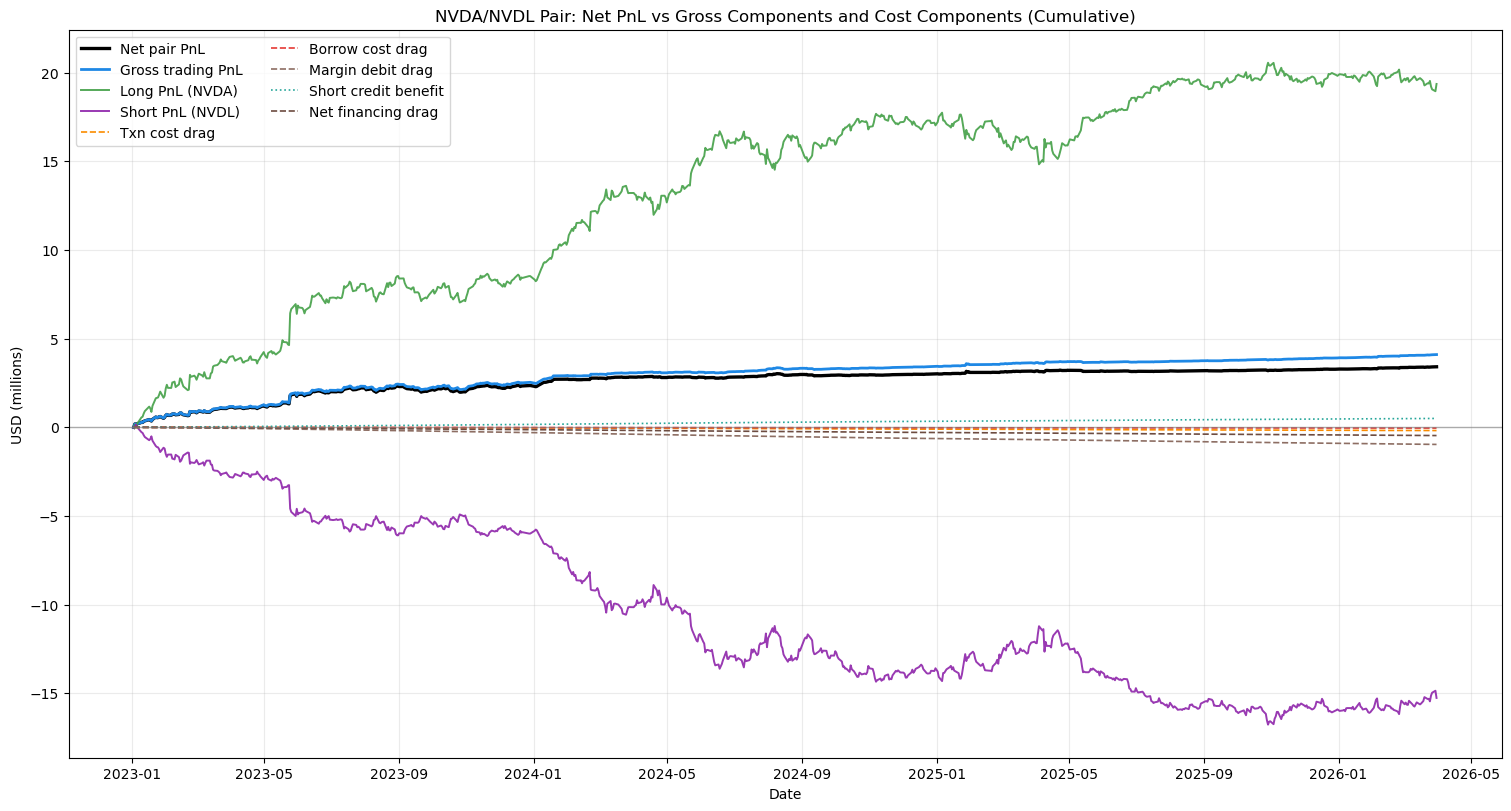

In [106]:
# ---- NVDA/NVDL cumulative PnL decomposition chart (net + gross + cost components) ----

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Use in-memory attribution table if available; otherwise load saved CSV.
if "out" in globals() and isinstance(out, pd.DataFrame) and len(out) > 0:
    d = out.copy()
else:
    p = Path("notebooks/data/backtest/daily_pair_attribution_NVDA_NVDL.csv")
    if not p.exists():
        p = Path("data/backtest/daily_pair_attribution_NVDA_NVDL.csv")
    if not p.exists():
        raise FileNotFoundError("Run the NVDA/NVDL attribution cell first (CSV not found).")
    d = pd.read_csv(p)

# Ensure required columns exist.
required = {
    "date",
    "cum_long_pnl_usd",
    "cum_short_pnl_usd",
    "cum_pair_gross_trading_pnl_usd",
    "cum_pair_alloc_total_cost_usd",
    "cum_pair_net_pnl_usd",
}
missing = [c for c in required if c not in d.columns]
if missing:
    raise RuntimeError(f"Missing required columns: {missing}. Re-run updated attribution cell.")

for c in [
    "cum_long_pnl_usd",
    "cum_short_pnl_usd",
    "cum_pair_gross_trading_pnl_usd",
    "cum_pair_alloc_total_cost_usd",
    "cum_pair_net_pnl_usd",
    "daily_pair_alloc_txn_cost_usd",
    "daily_pair_alloc_borrow_cost_usd",
    "daily_pair_alloc_margin_debit_cost_usd",
    "daily_pair_alloc_short_credit_income_usd",
    "daily_pair_alloc_net_financing_cost_usd",
]:
    if c in d.columns:
        d[c] = pd.to_numeric(d[c], errors="coerce")

# Build cumulative component curves for costs (as negative drag on same axis).
if "daily_pair_alloc_txn_cost_usd" in d.columns:
    d["cum_txn_drag_usd"] = -d["daily_pair_alloc_txn_cost_usd"].fillna(0.0).cumsum()
else:
    d["cum_txn_drag_usd"] = pd.NA
if "daily_pair_alloc_borrow_cost_usd" in d.columns:
    d["cum_borrow_drag_usd"] = -d["daily_pair_alloc_borrow_cost_usd"].fillna(0.0).cumsum()
else:
    d["cum_borrow_drag_usd"] = pd.NA
if "daily_pair_alloc_margin_debit_cost_usd" in d.columns:
    d["cum_margin_debit_drag_usd"] = -d["daily_pair_alloc_margin_debit_cost_usd"].fillna(0.0).cumsum()
else:
    d["cum_margin_debit_drag_usd"] = pd.NA
if "daily_pair_alloc_short_credit_income_usd" in d.columns:
    d["cum_short_credit_benefit_usd"] = d["daily_pair_alloc_short_credit_income_usd"].fillna(0.0).cumsum()
else:
    d["cum_short_credit_benefit_usd"] = pd.NA
if "daily_pair_alloc_net_financing_cost_usd" in d.columns:
    d["cum_financing_drag_usd"] = -d["daily_pair_alloc_net_financing_cost_usd"].fillna(0.0).cumsum()
else:
    d["cum_financing_drag_usd"] = pd.NA

d["date"] = pd.to_datetime(d["date"])
d = d.sort_values("date")

fig, ax = plt.subplots(figsize=(15, 8), layout="constrained")
ax.plot(d["date"], d["cum_pair_net_pnl_usd"] / 1e6, lw=2.4, color="black", label="Net pair PnL")
ax.plot(d["date"], d["cum_pair_gross_trading_pnl_usd"] / 1e6, lw=2.0, color="#1E88E5", label="Gross trading PnL")
ax.plot(d["date"], d["cum_long_pnl_usd"] / 1e6, lw=1.4, color="#43A047", alpha=0.9, label="Long PnL (NVDA)")
ax.plot(d["date"], d["cum_short_pnl_usd"] / 1e6, lw=1.4, color="#8E24AA", alpha=0.9, label="Short PnL (NVDL)")

if d["cum_txn_drag_usd"].notna().any():
    ax.plot(d["date"], d["cum_txn_drag_usd"] / 1e6, lw=1.2, ls="--", color="#FB8C00", label="Txn cost drag")
if d["cum_borrow_drag_usd"].notna().any():
    ax.plot(d["date"], d["cum_borrow_drag_usd"] / 1e6, lw=1.2, ls="--", color="#E53935", label="Borrow cost drag")
if d["cum_margin_debit_drag_usd"].notna().any():
    ax.plot(d["date"], d["cum_margin_debit_drag_usd"] / 1e6, lw=1.2, ls="--", color="#8D6E63", label="Margin debit drag")
if d["cum_short_credit_benefit_usd"].notna().any():
    ax.plot(d["date"], d["cum_short_credit_benefit_usd"] / 1e6, lw=1.2, ls=":", color="#26A69A", label="Short credit benefit")
if d["cum_financing_drag_usd"].notna().any():
    ax.plot(d["date"], d["cum_financing_drag_usd"] / 1e6, lw=1.2, ls="--", color="#6D4C41", label="Net financing drag")

ax.axhline(0.0, color="gray", lw=1.0, alpha=0.6)
ax.set_title("NVDA/NVDL Pair: Net PnL vs Gross Components and Cost Components (Cumulative)")
ax.set_xlabel("Date")
ax.set_ylabel("USD (millions)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", ncol=2)
plt.show()